In [ ]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────
DATA_ROOT  = "/path/to/data"        # root: {model}/{cls}/embs/
OUTPUT_DIR = "/path/to/outputs/foc" # where CSVs are written
LABELS_CSV = "/path/to/partial_mask_geometry_xai/models_and_data/class_labels_indices.csv"
# ─────────────────────────────────────────────────────────────────────────────
print(f"Data root : {DATA_ROOT}\n"
      f"Output dir: {OUTPUT_DIR}\n"
      f"Labels CSV: {LABELS_CSV}")


In [ ]:
import os
import numpy as np

os.makedirs(OUTPUT_DIR, exist_ok=True)

_DATA = DATA_ROOT
N_MASKS_PER_CLIP = 9600
MASK_DIMS = {
    "ast_wrapper": (128, 101),
    "panns_no_specaug": ( 64, 100),
    "panns_specaug_trained": ( 64, 100),
}
MODELS = ["ast_wrapper", "panns_no_specaug", "panns_specaug_trained"]
N_CLASSES = 527
CLASSES = [
    "bagpipes", "boing", "chicken_rooster", "didgeridoo", "dog", "drum_kit",
    "frog", "frying_food", "gunshot_gunfire", "hair_dryer", "harmonica",
    "heart_sounds_heartbeat", "insect", "owl", "rain", "rub", "sewing_machine",
    "speech", "thunder", "timpani", "train", "whispering",
]
print("Data root:", _DATA)
print("Models:", MODELS)
print(f"classes ({len(CLASSES)}):", CLASSES)
for m, (n_mels, n_time) in MASK_DIMS.items():
    print(f"  {m:<28}: mask shape (unpacked) ({N_MASKS_PER_CLIP}, {n_mels}, {n_time})")



# FOC Analysis — Initialisation

## Directory structure

All data lives under a single root:
```
{_DATA}/{model}/{cls}/
    embs/               ← per-clip sigmoid outputs and per-mask perturbation data
    masks/              ← per-clip perturbation masks (.npy, packed binary)
    attribution_maps/   ← per-clip attribution maps (.npy, float64)
    samples.csv         ← row-level lookup table for npz arrays (see below)
    summary.csv         ← class-level attribution summary
    errors.csv          ← class-level run errors
```

## samples.csv schema

`samples.csv` is a row-level index into the perturbation npz arrays — one row per mask application:

| Column | Description |
|---|---|
| `clip_id` | YouTube ID (e.g., `Y0474eRAlFLY`) |
| `model_id` | Full HuggingFace model identifier |
| `fill` | Fill condition used (e.g., `zero`) |
| `target` | **AudioSet ground-truth label** (e.g., `Bagpipes`) |
| `sample_idx` | Clip index within the class |
| `seed` | Random seed used for this mask |
| `confidence` | Scalar model confidence for `target` under this mask — matches `confs[row_idx]` |
| `occlusion_frac` | Fraction of cells occluded — matches `occ_fracs[row_idx]` |
| `perturb_npz_path` | Absolute path to the npz file for this clip × fill |
| `row_idx` | Index into the npz arrays (`logits[row_idx]`, `confs[row_idx]`, etc.) |

## Perturbation data (npz files)

**Path:** `{_DATA}/{model}/{cls}/embs/{ytID}_perturbations_{fill_type}.npz`

Contains per-mask outputs across all 9600 masks for a given clip and fill condition:

| Key | Shape | Description |
|---|---|---|
| `sigmoid` | `(9600, 527)` | Full sigmoid output vector under each mask — $f(S_{m^{(i)}})$ |
| `confs` | `(9600,)` | GT-label confidence per mask — equals `sigmoid[:, gt_idx[cls]]` |
| `occ_fracs` | `(9600,)` | Fraction of cells occluded per mask — retention $\alpha = 1 - \text{occ\_fracs}$ |
| `layer_N` | `(9600, D)` | Per-layer embeddings (see model-specific dims below) |
| `penultimate` | `(9600, D)` | Final pre-logit embedding |

Layer embedding dimensions vary by architecture:

| Model | Layers | Embedding dims |
|---|---|---|
| `ast_wrapper` | `layer_0`–`layer_11`, `penultimate` | 768 (transformer, fixed) |
| `panns_no_specaug` | `layer_0`–`layer_5`, `penultimate` | 64→128→256→512→1024→2048 (CNN14) |
| `panns_specaug_trained` | `layer_0`–`layer_5`, `penultimate` | 64→128→256→512→1024→2048 (CNN14) |

**Fill types** in filename: `zero`, `mean`, `gaussian_noise`

> `occ_fracs` is the fraction of cells set to 0 (occluded). Retention fraction $\alpha^{(i)} = 1 - \text{occ\_fracs}[i]$.

## FOC outputs (npy files)

**Path:** `{_DATA}/{model}/{cls}/embs/{ytID}_original_sigmoid.npy` and `{ytID}_foc_{fill}.npy`

Shape `(527,)` per clip — sigmoid probabilities, not raw logits, despite the filename.

## Masks

**Path:** `{_DATA}/{model}/{cls}/masks/{ytID}_masks.npy`

Stored as `uint8` packed binary (each byte encodes 8 bits). To load:
```python
masks = np.unpackbits(np.load(path), axis=1)               # (9600, N_MELS*N_TIME)
masks = masks.reshape(N_MASKS_PER_CLIP, n_mels, n_time)    # (9600, N_MELS, N_TIME)
```

Mask convention (confirmed from `perturbation.py`):
- `1` = **retained** (original audio passes through)
- `0` = **occluded** (region replaced by fill value)

Masks are generated at the **block level**: the spectrogram is partitioned into K_F=5 × K_T=5 = 25 blocks per seed, each block receiving an independent Bernoulli draw. Block boundaries shift per seed across the 9600 masks.

Spectrogram dimensions vary by model:

| Model | N_MELS | N_TIME | Packed width | Unpacked width |
|---|---|---|---|---|
| `ast_wrapper` | 128 | 101 | 1616 | 12928 |
| `panns_no_specaug` | 64 | 100 | 800 | 6400 |
| `panns_specaug_trained` | 64 | 100 | 800 | 6400 |

## Attribution maps

**Path:** `{_DATA}/{model}/{cls}/attribution_maps/{ytID}_{fill_type}.npy`

- Shape: `(N_MELS, N_TIME)` — same spatial grid as masks, no unpacking needed
- `float64`, continuous values, **can be negative**
- Computed as $\varphi_j = \mathbb{E}[f_k(S_m) \mid m_j=1] - \mathbb{E}[f_k(S_m) \mid m_j=0]$ across 9600 masks using the GT label $k$
- Positive: retaining that region increases target confidence (supports the class)
- Negative: retaining that region decreases target confidence (suppresses the class)
- `fill_type` in filename: `zero`, `mean`, `gaussian_noise`

In [8]:
import csv

_LABELS = LABELS_CSV

with open(_LABELS) as f:
    idx_to_name = {int(row["index"]): row["display_name"]
                   for row in csv.DictReader(f)}

print(f"Loaded {len(idx_to_name)} class labels")
print("Sample:", {k: idx_to_name[k] for k in range(3)})

Loaded 527 class labels
Sample: {0: 'Speech', 1: 'Male speech, man speaking', 2: 'Female speech, woman speaking'}


## Data Loading

We load four arrays for each (model, class) pair from the `embs/` directory:

- **Original** (`*_original_sigmoid.npy`): model outputs on unoccluded clips
- **FOC zero** (`*_foc_zero.npy`): entire spectrogram replaced with zeros
- **FOC mean** (`*_foc_mean.npy`): entire spectrogram replaced with time-averaged magnitude
- **FOC gaussian noise** (`*_foc_gaussian_noise.npy`): entire spectrogram replaced with gaussian noise

All arrays are shape `(n_clips, 527)` and contain **sigmoid probabilities** in [0, 1] sigmoid probabilities in [0, 1]. Each model is trained with BCE loss and independent per-class sigmoid outputs, so values are treated as independent Bernoulli confidences — not a probability simplex (do not softmax).

In [ ]:
FILL_SUFFIXES = {
    "foc_zero":           "_foc_zero.npy",
    "foc_mean":           "_foc_mean.npy",
    "foc_gaussian_noise": "_foc_gaussian_noise.npy",
}

data   = {}
totals = {"orig": 0, **{k: 0 for k in FILL_SUFFIXES}}

for model in MODELS:
    data[model] = {}
    for cls in CLASSES:
        embs_dir = os.path.join(_DATA, model, cls, "embs")
        if not os.path.isdir(embs_dir):
            print(f"  WARN: {model}/{cls}/embs not found")
            continue

        orig_files = sorted(f for f in os.listdir(embs_dir)
                            if f.endswith("_original_sigmoid.npy"))
        if not orig_files:
            print(f"  WARN: no original sigmoid for {model}/{cls}")
            continue

        n_orig = len(orig_files)
        data[model][cls] = {
            "orig": np.stack([np.load(os.path.join(embs_dir, f), allow_pickle=False).astype(np.float32)
                              for f in orig_files])  # (n_clips, 527)
        }
        totals["orig"] += n_orig

        for fill_key, suffix in FILL_SUFFIXES.items():
            fill_files = sorted(f for f in os.listdir(embs_dir) if f.endswith(suffix))
            if not fill_files:
                print(f"  WARN: no {fill_key} files for {model}/{cls}")
                continue
            if len(fill_files) != n_orig:
                print(f"  WARN: clip count mismatch {model}/{cls} {fill_key}: orig={n_orig} fill={len(fill_files)} — skipping")
                continue
            data[model][cls][fill_key] = np.stack([
                np.load(os.path.join(embs_dir, f), allow_pickle=False).astype(np.float32)
                for f in fill_files
            ])  # (n_clips, 527)
            totals[fill_key] += len(fill_files)

print(f"orig              : {totals['orig']}  (expected 3297)")
for k in FILL_SUFFIXES:
    print(f"{k:<22}: {totals[k]}  (expected 3297)")

orig              : 3297  (expected 3297)
foc_zero              : 3297  (expected 3297)
foc_mean              : 3297  (expected 3297)
foc_gaussian_noise    : 3297  (expected 3297)


### GT class index lookup

For each class the AudioSet index is looked up directly from `class_labels_indices.csv` by reversing the directory slug back to the display name. This is the same label the experiment runner used — attribution maps and `confs` in the npz files were both computed against it.

The index is **model-agnostic**: AudioSet class indices are fixed across all three models.

In [ ]:
def _slug(name):
    return (name.replace(", ", "_").replace(" ", "_").replace("(", "").replace(")", "").lower())

# Build slug → (index, display_name) using the same logic as main_experiment.py
slug_to_gt = {_slug(name): (idx, name) for idx, name in idx_to_name.items()}

# Resolve GT index for each class — model-agnostic
gt_idx     = {}   # cls → AudioSet integer index
gt_name    = {}   # cls → AudioSet display name

print(f"{'class':<28} {'idx':>5}  gt_label")
print("-" * 55)
for cls in CLASSES:
    if cls in slug_to_gt:
        idx, name = slug_to_gt[cls]
        gt_idx[cls]  = idx
        gt_name[cls] = name
        print(f"{cls:<28} {idx:>5}  {name}")
    else:
        print(f"{cls:<28}   ???  NO MATCH")

## Model accuracy on the eval set

For each (model, class) we compute the fraction of original clips where the model's argmax equals the GT index. This is **informational only** — we always probe the GT class index regardless of model accuracy.

Low accuracy means the model is systematically predicting a different class for those clips. The attribution maps and confidence values still track the GT label, but their magnitudes will be small when model accuracy is low.

In [ ]:
model_accuracy = {}  # model → cls → fraction of clips where argmax == GT index

for model in MODELS:
    model_accuracy[model] = {}
    print(f"\n{model}")
    print(f"  {'class':<28} {'accuracy':>10}  model top-1")
    print("  " + "-" * 60)
    for cls in CLASSES:
        if cls not in data[model] or cls not in gt_idx:
            continue
        k        = gt_idx[cls]
        argmaxes = np.argmax(data[model][cls]["orig"], axis=1)
        acc      = float((argmaxes == k).mean())
        top1_idx = int(np.bincount(argmaxes).argmax())
        top1     = idx_to_name.get(top1_idx, "?")
        model_accuracy[model][cls] = acc
        flag = "" if acc >= 0.5 else "  ← low"
        print(f"  {cls:<28} {acc:>9.0%}  {top1}{flag}")

## Core Analysis: GT Class Confidence Under Each Fill Condition

For each (model, class, fill) triple we compute the following metrics at the **GT class index** (`gt_idx`), comparing original audio against each fill condition:

| Metric | Definition |
|---|---|
| `gt_sigmoid` | Mean sigmoid output at `gt_idx` across original clips — how confidently the model predicts the correct class on clean audio |
| `gt_sigmoid_std` | Std of that sigmoid value across clips (ddof=1) — clip-to-clip variability |
| `foc_gt_sigmoid` | Mean sigmoid output at `gt_idx` when the entire spectrogram is replaced by the fill — the fill's intrinsic activation of the GT class |
| `delta_gt_sigmoid` | `foc_gt_sigmoid − gt_sigmoid` — how much the fill shifts GT class confidence (always negative) |
| `gt_rank` | Mean rank of the GT class in the original output (pessimistic dense rank: how many classes score ≥ GT class, averaged across clips). Rank 1 = the correct class is the top prediction |
| `foc_gt_rank` | Same rank under the fill condition — will be much higher because the fill destroys the signal |
| `entropy` | Mean binary entropy of the full 527-class output vector on original audio. High entropy = many classes activated simultaneously, low = output is concentrated |
| `foc_entropy` | Same entropy under the fill condition |
| `delta_entropy` | `foc_entropy − entropy` — positive means the fill spreads activation across more classes; negative means it collapses the distribution |
| `acc` | Fraction of original clips where model argmax == `gt_idx` (informational — low means the model fires on a parent class instead) |

> **Entropy.** $H_{\text{binary}}(\mathbf{s}) = \sum_{k=1}^{527} [-s_k \log_2 s_k - (1-s_k)\log_2(1-s_k)]$, treating each output as an independent Bernoulli — consistent with BCE training. Reported as mean-of-per-clip-entropies to avoid Jensen's inequality overstatement.

> **Orig stats precomputed.** `gt_sigmoid`, `gt_sigmoid_std`, `gt_rank`, and `entropy` depend only on the original clips and are precomputed once outside the fill loop — their values are identical across all three fill conditions for a given (model, class).

In [ ]:
EPS = 1e-10

def binary_entropy_mat(M):
    """Multi-label binary entropy for a (n, 527) matrix — returns (n,) array of bits."""
    M = np.clip(M, EPS, 1 - EPS)
    return -np.sum(M * np.log2(M) + (1 - M) * np.log2(1 - M), axis=1)

KEYS = ["gt_sigmoid", "gt_sigmoid_std", "foc_gt_sigmoid", "delta_gt_sigmoid", "gt_rank", "foc_gt_rank", "entropy", "foc_entropy", "delta_entropy"]

def _row(label, s):
    return (f"  {label:<38} "
            f"{np.mean(s['gt_sigmoid']):7.4f} {np.nanmean(s['gt_sigmoid_std']):7.4f} "
            f"{np.mean(s['foc_gt_sigmoid']):7.4f} {np.mean(s['delta_gt_sigmoid']):+8.4f} "
            f"{np.mean(s['gt_rank']):7.1f} {np.mean(s['foc_gt_rank']):7.1f} "
            f"{np.mean(s['entropy']):7.2f} {np.mean(s['foc_entropy']):7.2f} {np.mean(s['delta_entropy']):+7.2f}")

def _std(label, s):
    n = len(s["gt_sigmoid"])
    if n < 2:
        return f"  {label:<38} n/a (n<2)"
    return (f"  {label:<38} "
            f"{np.std(s['gt_sigmoid'], ddof=1):7.4f} {'n/a':>7} "
            f"{np.std(s['foc_gt_sigmoid'], ddof=1):7.4f} {np.std(s['delta_gt_sigmoid'], ddof=1):+8.4f} "
            f"{np.std(s['gt_rank'], ddof=1):7.1f} {np.std(s['foc_gt_rank'], ddof=1):7.1f} "
            f"{np.std(s['entropy'], ddof=1):7.2f} {np.std(s['foc_entropy'], ddof=1):7.2f} {np.std(s['delta_entropy'], ddof=1):+7.2f}")

header = (f"{'Model':<24} {'class':<22} "
          f"{'gt_sig':>7} {'sig_std':>7} {'foc_sig':>7} {'delta':>8} "
          f"{'gt_rank':>7} {'foc_rank':>8} "
          f"{'entropy':>7} {'foc_ent':>7} {'dent':>7} {'acc':>6}")

# Pre-compute orig_* stats once (depend only on original clips, not fill condition)
orig_stats = {}
for model in MODELS:
    orig_stats[model] = {}
    for cls in CLASSES:
        if cls not in data[model] or cls not in gt_idx:
            continue
        orig_vecs = data[model][cls]["orig"]
        n_clips   = orig_vecs.shape[0]
        k         = gt_idx[cls]
        orig_at_k = orig_vecs[:, k]
        orig_stats[model][cls] = {
            "gt_sigmoid":     float(orig_at_k.mean()),
            "gt_sigmoid_std": float(orig_at_k.std(ddof=1)) if n_clips > 1 else float("nan"),
            "gt_rank":        float(np.mean(np.sum(orig_vecs >= orig_vecs[:, k:k+1], axis=1))),
            "entropy":        float(binary_entropy_mat(orig_vecs).mean()),
        }

all_rows = []

for fill in FILL_SUFFIXES:
    print(f"\n{'='*50} {fill} {'='*50}")
    print(header)
    print("-" * 120)

    summary = {m: {key: [] for key in KEYS} for m in MODELS}

    for model in MODELS:
        for cls in CLASSES:
            if cls not in data[model] or fill not in data[model][cls] or cls not in orig_stats.get(model, {}):
                continue

            os_              = orig_stats[model][cls]
            gt_sigmoid       = os_["gt_sigmoid"]
            gt_sigmoid_std   = os_["gt_sigmoid_std"]
            gt_rank          = os_["gt_rank"]
            entropy          = os_["entropy"]
            k                = gt_idx[cls]
            acc              = model_accuracy.get(model, {}).get(cls, float("nan"))

            foc_vecs         = data[model][cls][fill]   # (n_clips, 527)
            foc_gt_sigmoid   = float(foc_vecs[:, k].mean())
            delta_gt_sigmoid = foc_gt_sigmoid - gt_sigmoid
            foc_gt_rank      = float(np.mean(np.sum(foc_vecs >= foc_vecs[:, k:k+1], axis=1)))
            foc_entropy      = float(binary_entropy_mat(foc_vecs).mean())
            delta_entropy    = foc_entropy - entropy

            vals = dict(gt_sigmoid=gt_sigmoid, gt_sigmoid_std=gt_sigmoid_std, foc_gt_sigmoid=foc_gt_sigmoid, delta_gt_sigmoid=delta_gt_sigmoid, gt_rank=gt_rank, foc_gt_rank=foc_gt_rank, entropy=entropy, foc_entropy=foc_entropy, delta_entropy=delta_entropy,)
            for key, v in vals.items():
                summary[model][key].append(v)

            all_rows.append({
                "model":            model,
                "class":            cls,
                "fill":             fill,
                "gt_idx":           k,
                "gt_label":         gt_name.get(cls, "?"),
                "accuracy":         round(acc, 4) if not np.isnan(acc) else float("nan"),
                "gt_sigmoid":       round(gt_sigmoid, 6),
                "gt_sigmoid_std":   float("nan") if np.isnan(gt_sigmoid_std) else round(gt_sigmoid_std, 6),
                "foc_gt_sigmoid":   round(foc_gt_sigmoid, 6),
                "delta_gt_sigmoid": round(delta_gt_sigmoid, 6),
                "gt_rank":          round(gt_rank, 2),
                "foc_gt_rank":      round(foc_gt_rank, 2),
                "entropy":          round(entropy, 4),
                "foc_entropy":      round(foc_entropy, 4),
                "delta_entropy":    round(delta_entropy, 4),
            })

            std_str = f"{gt_sigmoid_std:7.4f}" if not np.isnan(gt_sigmoid_std) else "    nan"
            acc_str = f"{acc:5.0%}" if not np.isnan(acc) else "  n/a"
            print(f"{model:<24} {cls:<22} "
                  f"{gt_sigmoid:7.4f} {std_str} {foc_gt_sigmoid:7.4f} {delta_gt_sigmoid:+8.4f} "
                  f"{gt_rank:7.1f} {foc_gt_rank:8.1f} "
                  f"{entropy:7.2f} {foc_entropy:7.2f} {delta_entropy:+7.2f} {acc_str:>6}")

        s = summary[model]
        n = len(s["gt_sigmoid"])
        print(_row(f"({n}) MEAN", s))
        print(_std(f"({n}) STD",  s))
        print()

print(f"\nCollected {len(all_rows)} rows total  "
      f"({len(MODELS)} models × {len(CLASSES)} classes × {len(FILL_SUFFIXES)} fills = "
      f"{len(MODELS)*len(CLASSES)*len(FILL_SUFFIXES)} expected)")

In [ ]:
_CSV_OUT = os.path.join(OUTPUT_DIR, "foc_analysis.csv")

fieldnames = [
    "model", "class", "fill",
    "gt_idx", "gt_label", "accuracy",
    "gt_sigmoid", "gt_sigmoid_std", "foc_gt_sigmoid", "delta_gt_sigmoid",
    "gt_rank", "foc_gt_rank",
    "entropy", "foc_entropy", "delta_entropy",
]

with open(_CSV_OUT, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_rows)

print(f"Saved {len(all_rows)} rows → {_CSV_OUT}")

## FOC Table — Top-1/Top-2 Class Distribution and Entropy

For each (model, fill) combination, pools all clips across all 22 GT classes (~1099 per model) and computes:

- **Modal top-1 / top-2**: most frequently occurring top-1 and top-2 predicted class across all pooled clips
- **p ± σ**: mean and std of sigmoid confidence for that class, computed only over clips where it was predicted as top-1 (or top-2). Zero fill is signal-independent so σ = 0.
- **H**: binary Shannon entropy of the mean sigmoid vector across all clips. H ∈ [0, 527] bits; maximum is 527 bits (all classes at 0.5).
- **Top-2 H weight**: fraction of total H accounted for by the top-1 and top-2 classes' individual binary entropies. Low weight = uncertainty is spread across many classes; high weight = concentrated in the top two.

In [ ]:
import numpy as np

EPS = 1e-10

FILL_KEYS = ["foc_zero", "foc_mean", "foc_gaussian_noise"]
FILL_DISPLAY = {
    "foc_zero":           "Zero",
    "foc_mean":           "Mean",
    "foc_gaussian_noise": "Gaussian noise",
}

foc_table = {}  # [model][fill_key] → dict of stats

for model in MODELS:
    foc_table[model] = {}

    for fill_key in FILL_KEYS:
        # Pool all clips from all 22 GT classes
        parts = [data[model][cls][fill_key]
                 for cls in CLASSES
                 if cls in data[model] and fill_key in data[model][cls]]

        if not parts:
            print(f"  WARN: no data for {model} / {fill_key}")
            continue

        pooled = np.concatenate(parts, axis=0).astype(np.float32)  # (N, 527)
        N = pooled.shape[0]

        # Mean sigmoid vector across all clips — used for modal class selection and display
        mean_vec = pooled.mean(axis=0)   # (527,)

        # Modal top-1: class with highest mean sigmoid across all clips.
        modal_top1 = int(mean_vec.argmax())

        # Modal top-2: class with second highest mean sigmoid, excluding modal_top1
        mean_vec_excl = mean_vec.copy()
        mean_vec_excl[modal_top1] = -1.0
        modal_top2 = int(mean_vec_excl.argmax())

        top1_idx = np.argmax(pooled, axis=1)
        top2_idx = np.argsort(-pooled, axis=1)[:, 1]

        n_top1 = int((top1_idx == modal_top1).sum())
        n_top2 = int((top2_idx == modal_top2).sum())

        # --- Conditional p ± σ: only clips where that class was ranked top-1 / top-2 ---
        p1_vals = pooled[top1_idx == modal_top1, modal_top1]
        p2_vals = pooled[top2_idx == modal_top2, modal_top2]

        p1_mean = float(p1_vals.mean()) if len(p1_vals) > 0 else float("nan")
        p1_std  = float(p1_vals.std(ddof=1)) if len(p1_vals) > 1 else 0.0
        p2_mean = float(p2_vals.mean()) if len(p2_vals) > 0 else float("nan")
        p2_std  = float(p2_vals.std(ddof=1)) if len(p2_vals) > 1 else 0.0

        # --- Unconditional p ± σ: all clips regardless of rank ---
        p1_all_vals = pooled[:, modal_top1]
        p2_all_vals = pooled[:, modal_top2]

        p1_all_mean = float(p1_all_vals.mean())
        p1_all_std  = float(p1_all_vals.std(ddof=1)) if N > 1 else 0.0
        p2_all_mean = float(p2_all_vals.mean())
        p2_all_std  = float(p2_all_vals.std(ddof=1)) if N > 1 else 0.0

        # Zero fill: verify signal independence within each GT class separately.
        if fill_key == "foc_zero":
            for cls in CLASSES:
                if cls in data[model] and fill_key in data[model][cls]:
                    within_std = float(data[model][cls][fill_key].std(axis=0).max())
                    if within_std > 1e-4:
                        print(f"  WARN: zero fill within {cls}/{model} max std = {within_std:.6f}")

        # E[H(q)] — mean of per-clip binary entropies, decomposed per class.
        # Cast to float64: float32 cannot represent (1 - 1e-10), producing nan.
        p64         = np.clip(pooled.astype(np.float64), EPS, 1 - EPS)
        per_class_h = (-p64 * np.log2(p64)
                       - (1 - p64) * np.log2(1 - p64)).mean(axis=0)  # (527,)
        H_total = float(per_class_h.sum())

        h1 = float(per_class_h[modal_top1])
        h2 = float(per_class_h[modal_top2])
        h_top2        = h1 + h2
        h_top2_weight = h_top2 / H_total if H_total > 0 else float("nan")

        foc_table[model][fill_key] = {
            "N":               N,
            "modal_top1":      modal_top1,
            "modal_top1_name": idx_to_name.get(modal_top1, "?"),
            "n_top1":          n_top1,
            "p1_mean":         p1_mean,        # conditional (when ranked top-1)
            "p1_std":          p1_std,
            "p1_all_mean":     p1_all_mean,    # unconditional (all clips)
            "p1_all_std":      p1_all_std,
            "modal_top2":      modal_top2,
            "modal_top2_name": idx_to_name.get(modal_top2, "?"),
            "n_top2":          n_top2,
            "p2_mean":         p2_mean,        # conditional (when ranked top-2)
            "p2_std":          p2_std,
            "p2_all_mean":     p2_all_mean,    # unconditional (all clips)
            "p2_all_std":      p2_all_std,
            "mean_vec":        mean_vec,
            "per_class_h":     per_class_h,
            "H_total":         H_total,
            "h1":              h1,
            "h2":              h2,
            "h_top2":          h_top2,
            "h_top2_weight":   h_top2_weight,
        }

print("FOC table computed.  H = E[H(q)] — mean of per-clip binary entropies.")
print()
print(f"{'model':<28} {'fill':<18} {'N':>5}  "
      f"top-1 class              n/N    p|top1±σ         p|all±σ           "
      f"top-2 class              n/N    p|top2±σ         p|all±σ           "
      f"H (bits)  top-2 wt")
print("-" * 240)

MODEL_LABELS = {
    "ast_wrapper":           "AST",
    "panns_no_specaug":      "PANNs (no SA)",
    "panns_specaug_trained": "PANNs (+SA)",
}

for model in MODELS:
    for fill_key in FILL_KEYS:
        if fill_key not in foc_table[model]:
            continue
        r = foc_table[model][fill_key]
        is_zero = fill_key == "foc_zero"
        p1c = f"{r['p1_mean']:.3f}" if is_zero else f"{r['p1_mean']:.3f}±{r['p1_std']:.3f}"
        p1u = f"{r['p1_all_mean']:.3f}" if is_zero else f"{r['p1_all_mean']:.3f}±{r['p1_all_std']:.3f}"
        p2c = f"{r['p2_mean']:.3f}" if is_zero else f"{r['p2_mean']:.3f}±{r['p2_std']:.3f}"
        p2u = f"{r['p2_all_mean']:.3f}" if is_zero else f"{r['p2_all_mean']:.3f}±{r['p2_all_std']:.3f}"
        print(f"{MODEL_LABELS[model]:<28} {FILL_DISPLAY[fill_key]:<18} {r['N']:>5}  "
              f"{r['modal_top1_name']:<24} {r['n_top1']:>4}/{r['N']}  {p1c:<16}  {p1u:<16}  "
              f"{r['modal_top2_name']:<24} {r['n_top2']:>4}/{r['N']}  {p2c:<16}  {p2u:<16}  "
              f"{r['H_total']:>8.3f}   {r['h_top2_weight']:>6.3f}")

# --- Per-model top-2 summary for signal-dependent fills ---
print()
print("─" * 70)
print("Top-2 by mean sigmoid — signal-dependent fills (mean & Gaussian noise)")
print("─" * 70)
for model in MODELS:
    for fill_key in ["foc_mean", "foc_gaussian_noise"]:
        if fill_key not in foc_table.get(model, {}):
            continue
        r = foc_table[model][fill_key]
        mv = r["mean_vec"]
        ranked = np.argsort(-mv)
        k1, k2 = int(ranked[0]), int(ranked[1])
        print(f"  {MODEL_LABELS[model]:<14} {FILL_DISPLAY[fill_key]:<16}"
              f"  1. {idx_to_name.get(k1,'?'):<28}  p̄ = {mv[k1]:.4f}"
              f"  |  2. {idx_to_name.get(k2,'?'):<28}  p̄ = {mv[k2]:.4f}")

In [ ]:
import csv

_FOC_TABLE_CSV = os.path.join(OUTPUT_DIR, "foc_table.csv")

_FIELDS = [
    "model", "fill", "N",
    "modal_top1", "modal_top1_name", "n_top1",
    "p1_mean", "p1_std",           # conditional: clips where class was top-1
    "p1_all_mean", "p1_all_std",   # unconditional: all clips
    "modal_top2", "modal_top2_name", "n_top2",
    "p2_mean", "p2_std",           # conditional: clips where class was top-2
    "p2_all_mean", "p2_all_std",   # unconditional: all clips
    "H_total", "h1", "h2", "h_top2", "h_top2_weight",
]

rows = []
for model in MODELS:
    for fill_key in FILL_KEYS:
        if fill_key not in foc_table.get(model, {}):
            continue
        r = foc_table[model][fill_key]
        rows.append({
            "model":           model,
            "fill":            fill_key,
            "N":               r["N"],
            "modal_top1":      r["modal_top1"],
            "modal_top1_name": r["modal_top1_name"],
            "n_top1":          r["n_top1"],
            "p1_mean":         round(r["p1_mean"],     6),
            "p1_std":          round(r["p1_std"],      6),
            "p1_all_mean":     round(r["p1_all_mean"], 6),
            "p1_all_std":      round(r["p1_all_std"],  6),
            "modal_top2":      r["modal_top2"],
            "modal_top2_name": r["modal_top2_name"],
            "n_top2":          r["n_top2"],
            "p2_mean":         round(r["p2_mean"],     6),
            "p2_std":          round(r["p2_std"],      6),
            "p2_all_mean":     round(r["p2_all_mean"], 6),
            "p2_all_std":      round(r["p2_all_std"],  6),
            "H_total":         round(r["H_total"],        6),
            "h1":              round(r["h1"],             6),
            "h2":              round(r["h2"],             6),
            "h_top2":          round(r["h_top2"],         6),
            "h_top2_weight":   round(r["h_top2_weight"],  6),
        })

with open(_FOC_TABLE_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=_FIELDS)
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved {len(rows)} rows → {_FOC_TABLE_CSV}")

In [ ]:
# Per-GT-class top-1 under mean and Gaussian fills (heatmap data)
# For each (model, fill, GT-class) find the modal top-1 class by mean sigmoid.
# Zero fill is signal-independent — per-class breakdown adds no information there.

HEATMAP_FILLS = ["foc_mean", "foc_gaussian_noise"]

foc_per_class_top1 = {}   # [model][fill_key][cls] → dict

print("Per-GT-class modal top-1 under mean and Gaussian fills")
print(f"{'model':<28} {'fill':<22} {'GT class':<28}  top-1 class              p_mean")
print("-" * 100)

for model in MODELS:
    foc_per_class_top1[model] = {}
    for fill_key in HEATMAP_FILLS:
        foc_per_class_top1[model][fill_key] = {}
        for cls in CLASSES:
            if cls not in data[model] or fill_key not in data[model][cls]:
                continue
            arr      = data[model][cls][fill_key].astype(np.float64)   # (n_clips, 527)
            mean_vec = arr.mean(axis=0)
            top1_idx  = int(mean_vec.argmax())
            top1_name = idx_to_name.get(top1_idx, "?")
            top1_p    = float(mean_vec[top1_idx])
            foc_per_class_top1[model][fill_key][cls] = {
                "top1_idx":  top1_idx,
                "top1_name": top1_name,
                "top1_p":    top1_p,
            }
            print(f"{MODEL_LABELS[model]:<28} {FILL_DISPLAY[fill_key]:<22} {cls:<28}  {top1_name:<24} {top1_p:.3f}")
        print()

# Heatmap aggregate: count how many GT classes share each top-1 class
print()
print("Heatmap counts (n GT classes → top-1 class)")
print(f"{'model':<28} {'fill':<22}  top-1 class              count/22")
print("-" * 80)
for model in MODELS:
    for fill_key in HEATMAP_FILLS:
        from collections import Counter
        counts = Counter(v["top1_name"]
                         for v in foc_per_class_top1[model][fill_key].values())
        n_total = len(foc_per_class_top1[model][fill_key])
        for name, cnt in counts.most_common():
            print(f"{MODEL_LABELS[model]:<28} {FILL_DISPLAY[fill_key]:<22}  {name:<24} {cnt}/{n_total}")
        print()

# Save to CSV
_HEATMAP_CSV = os.path.join(OUTPUT_DIR, "foc_per_class_top1.csv")
_HEATMAP_FIELDS = ["model", "fill_key", "gt_cls", "top1_idx", "top1_name", "top1_p"]
heatmap_rows = []
for model in MODELS:
    for fill_key in HEATMAP_FILLS:
        for cls in CLASSES:
            entry = foc_per_class_top1[model].get(fill_key, {}).get(cls)
            if entry is None:
                continue
            heatmap_rows.append({
                "model":    model,
                "fill_key": fill_key,
                "gt_cls":   cls,
                "top1_idx": entry["top1_idx"],
                "top1_name":entry["top1_name"],
                "top1_p":   round(entry["top1_p"], 6),
            })

import csv
with open(_HEATMAP_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=_HEATMAP_FIELDS)
    writer.writeheader()
    writer.writerows(heatmap_rows)
print(f"Saved {len(heatmap_rows)} rows → {_HEATMAP_CSV}")


## Reference — Original (Unoccluded) Entropy

Computes binary Shannon entropy of the mean sigmoid vector across all original (unoccluded) clips, pooled across all 22 GT classes per model. This is the baseline against which FOC entropy is compared — it tells us how spread the model's output distribution is on clean audio, giving context for how much the fill either concentrates or diffuses the model's predictions.

In [ ]:
import csv   # explicit import — do not rely on prior cell having run

orig_ref = {}       # [model] → pooled stats
orig_per_cls = {}   # [model][cls] → per-class stats

print("Per-class H on original (unoccluded) clips")
print(f"{'model':<28} {'class':<28} {'n':>5}  H_mean (bits)   H_std")
print("-" * 85)

for model in MODELS:
    orig_per_cls[model] = {}
    for cls in CLASSES:
        if cls not in data[model] or "orig" not in data[model][cls]:
            continue

        cls_vecs = data[model][cls]["orig"].astype(np.float64)   # (n_clips, 527)
        n_cls    = cls_vecs.shape[0]

        p64_cls    = np.clip(cls_vecs, EPS, 1 - EPS)
        H_mat_cls  = -p64_cls * np.log2(p64_cls) - (1 - p64_cls) * np.log2(1 - p64_cls)
        per_clip_H = H_mat_cls.sum(axis=1)   # (n_clips,)

        H_cls_mean = float(per_clip_H.mean())
        H_cls_std  = float(per_clip_H.std(ddof=1)) if n_cls > 1 else 0.0

        orig_per_cls[model][cls] = {"n": n_cls, "H_mean": H_cls_mean, "H_std": H_cls_std}
        print(f"{MODEL_LABELS[model]:<28} {cls:<28} {n_cls:>5}  {H_cls_mean:>13.3f}   {H_cls_std:.3f}")

    print()

# --- Per-model pooled stats ---
print("=" * 85)
print("Per-model pooled H on original clips (mean ± std across all clips)")
print(f"{'model':<28}  {'N':>5}  H_mean (bits)   H_std   top-1 class              n/N    p1±σ")
print("-" * 110)

for model in MODELS:
    parts = [data[model][cls]["orig"]
             for cls in CLASSES
             if cls in data[model] and "orig" in data[model][cls]]

    if not parts:
        print(f"  WARN: no original data for {model}")
        continue

    pooled = np.concatenate(parts, axis=0).astype(np.float64)   # (N, 527) — float64 throughout
    N = pooled.shape[0]

    mean_vec = pooled.mean(axis=0)   # (527,)

    modal_top1 = int(mean_vec.argmax())
    mean_vec_excl = mean_vec.copy()
    mean_vec_excl[modal_top1] = -1.0
    modal_top2 = int(mean_vec_excl.argmax())

    top1_idx = np.argmax(pooled, axis=1)
    top2_idx = np.argsort(-pooled, axis=1)[:, 1]
    n_top1 = int((top1_idx == modal_top1).sum())
    n_top2 = int((top2_idx == modal_top2).sum())

    p1_vals     = pooled[top1_idx == modal_top1, modal_top1]
    p2_vals     = pooled[top2_idx == modal_top2, modal_top2]
    p1_all_vals = pooled[:, modal_top1]
    p2_all_vals = pooled[:, modal_top2]

    # Compute entropy matrix once — derive per-clip H and per-class H from the same array
    p64    = np.clip(pooled, EPS, 1 - EPS)
    H_mat  = -p64 * np.log2(p64) - (1 - p64) * np.log2(1 - p64)   # (N, 527)
    per_clip_H  = H_mat.sum(axis=1)    # (N,)   — per-clip total H
    per_class_h = H_mat.mean(axis=0)   # (527,) — per-class mean H across clips

    H_mean  = float(per_clip_H.mean())
    H_std   = float(per_clip_H.std(ddof=1)) if N > 1 else 0.0
    H_total = float(per_class_h.sum())   # == H_mean by linearity of expectation

    h1 = float(per_class_h[modal_top1])
    h2 = float(per_class_h[modal_top2])
    h_top2        = h1 + h2
    h_top2_weight = h_top2 / H_total if H_total > 0 else float("nan")

    p1_std_print = float(p1_vals.std(ddof=1)) if len(p1_vals) > 1 else 0.0

    orig_ref[model] = {
        "N":               N,
        "mean_vec":        mean_vec,
        "per_class_h":     per_class_h,
        "H_mean":          H_mean,
        "H_std":           H_std,
        "H_total":         H_total,
        "modal_top1":      modal_top1,
        "modal_top1_name": idx_to_name.get(modal_top1, "?"),
        "n_top1":          n_top1,
        "p1_mean":         float(p1_vals.mean()) if len(p1_vals) > 0 else float("nan"),
        "p1_std":          float(p1_vals.std(ddof=1)) if len(p1_vals) > 1 else 0.0,
        "p1_all_mean":     float(p1_all_vals.mean()),
        "p1_all_std":      float(p1_all_vals.std(ddof=1)) if N > 1 else 0.0,
        "modal_top2":      modal_top2,
        "modal_top2_name": idx_to_name.get(modal_top2, "?"),
        "n_top2":          n_top2,
        "p2_mean":         float(p2_vals.mean()) if len(p2_vals) > 0 else float("nan"),
        "p2_std":          float(p2_vals.std(ddof=1)) if len(p2_vals) > 1 else 0.0,
        "p2_all_mean":     float(p2_all_vals.mean()),
        "p2_all_std":      float(p2_all_vals.std(ddof=1)) if N > 1 else 0.0,
        "h1":              h1,
        "h2":              h2,
        "h_top2":          h_top2,
        "h_top2_weight":   h_top2_weight,
    }

    print(f"{MODEL_LABELS[model]:<28}  {N:>5}  {H_mean:>13.3f}   {H_std:>5.3f}   "
          f"{idx_to_name.get(modal_top1,'?'):<24} {n_top1:>4}/{N}  "
          f"{float(p1_vals.mean()) if len(p1_vals) > 0 else float('nan'):.3f}"
          f"±{p1_std_print:.3f}")

# --- Delta H vs FOC ---
print()
print("Delta H = H_FOC_mean - H_orig_mean  (positive = fill spreads output)")
print(f"{'model':<28} {'fill':<18}  H_orig    H_foc   delta_H")
print("-" * 75)
for model in MODELS:
    if model not in orig_ref:
        continue
    H_orig = orig_ref[model]["H_mean"]
    for fill_key in FILL_KEYS:
        if fill_key not in foc_table.get(model, {}):
            continue
        H_foc   = foc_table[model][fill_key]["H_total"]
        delta_H = H_foc - H_orig
        print(f"{MODEL_LABELS[model]:<28} {FILL_DISPLAY[fill_key]:<18}  {H_orig:>6.3f}   {H_foc:>6.3f}  {delta_H:>+7.3f}")

# --- Save orig_ref (pooled) to CSV ---
_ORIG_CSV = os.path.join(OUTPUT_DIR, "foc_orig_ref.csv")
_ORIG_FIELDS = [
    "model", "N", "H_mean", "H_std",
    "modal_top1", "modal_top1_name", "n_top1",
    "p1_mean", "p1_std", "p1_all_mean", "p1_all_std",
    "modal_top2", "modal_top2_name", "n_top2",
    "p2_mean", "p2_std", "p2_all_mean", "p2_all_std",
    "H_total", "h1", "h2", "h_top2", "h_top2_weight",
]
orig_rows = []
for model in MODELS:
    if model not in orig_ref:
        continue
    r = orig_ref[model]
    # "model" is not stored in r — inject it; skip numpy arrays (mean_vec, per_class_h)
    orig_rows.append(
        {"model": model} | {f: round(r[f], 6) if isinstance(r[f], float) else r[f]
                            for f in _ORIG_FIELDS if f != "model"}
    )

with open(_ORIG_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=_ORIG_FIELDS)
    writer.writeheader()
    writer.writerows(orig_rows)
print(f"\nSaved {len(orig_rows)} rows → {_ORIG_CSV}")

# --- Save per-class H to CSV ---
_PER_CLS_CSV = os.path.join(OUTPUT_DIR, "foc_orig_per_class_H.csv")
_PER_CLS_FIELDS = ["model", "cls", "n", "H_mean", "H_std"]
per_cls_rows = []
for model in MODELS:
    for cls in CLASSES:
        if cls not in orig_per_cls.get(model, {}):
            continue
        r = orig_per_cls[model][cls]
        per_cls_rows.append({
            "model":  model,
            "cls":    cls,
            "n":      r["n"],
            "H_mean": round(r["H_mean"], 6),
            "H_std":  round(r["H_std"],  6),
        })

with open(_PER_CLS_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=_PER_CLS_FIELDS)
    writer.writeheader()
    writer.writerows(per_cls_rows)
print(f"Saved {len(per_cls_rows)} rows → {_PER_CLS_CSV}")

## Visualisations

# FOC Analysis — Visualisations

Three outputs for the meeting:

1. **Table 1** — Zero-fill model fingerprint: which class the fill 'sounds like' per model, entropy, and how much the top-5 explains.
2. **Figure 1** — Mean FOC residual entropy by model × fill (grouped bar). Overview of all 9 conditions.
3. **Figure 2** — Per-class entropy variation under mean fill (strip plot). Shows AST is class-specific; PANNs-noSA is generic confusion.
4. **Figure 3** — Entropy concentration scatter: total entropy vs fraction explained by top-5, per model × fill.

Data: `foc_analysis.csv` — computed by `compute_foc_analysis.py` on Apocrita, copied locally.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

_DATA       = OUTPUT_DIR
CSV_PATH    = os.path.join(_DATA, "foc_analysis.csv")
LABELS_PATH = LABELS_CSV

print(f"CSV exists   : {os.path.exists(CSV_PATH)}")
print(f"Labels exists: {os.path.exists(LABELS_PATH)}")

FILLS  = ["zero", "mean", "gaussian_noise"]
MODELS = ["ast_wrapper", "panns_no_specaug", "panns_specaug_trained"]

MODEL_LABELS = {
    "ast_wrapper":           "AST",
    "panns_no_specaug":      "PANNs (no SA)",
    "panns_specaug_trained": "PANNs (SA)",
}
FILL_LABELS = {
    "zero":           "Zero",
    "mean":           "Mean",
    "gaussian_noise": "Gaussian noise",
}
COLORS = {"zero": "#ef7b45", "mean": "#5eb1bf", "gaussian_noise": "#918ef4"}
MODEL_COLORS = {
    "ast_wrapper":           "#2C5F8A",
    "panns_no_specaug":      "#6B3D7A",
    "panns_specaug_trained": "#2D6A4F",
}
MODEL_MARKERS = {
    "ast_wrapper":           "o",
    "panns_no_specaug":      "s",
    "panns_specaug_trained": "^",
}

plt.rcParams.update({
    "figure.dpi":                    300,
    "font.family":                   "serif",
    "font.size":                     8,
    "axes.labelsize":                8,
    "axes.titlesize":                8,
    "xtick.labelsize":               7,
    "ytick.labelsize":               7,
    "legend.fontsize":               7,
    "legend.frameon":                False,
    "lines.linewidth":               1.5,
    "axes.spines.top":               False,
    "axes.spines.right":             False,
    "axes.linewidth":                0.6,
    "xtick.major.width":             0.6,
    "ytick.major.width":             0.6,
    "xtick.major.size":              3,
    "ytick.major.size":              3,
    "figure.constrained_layout.use": True,
})

In [5]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows")
print(f"Models  : {df['model'].unique().tolist()}")
print(f"Fills   : {df['fill'].unique().tolist()}")
print(f"Classes : {df['class'].nunique()} — {sorted(df['class'].unique().tolist())}")

# Class index → display name
ldf = pd.read_csv(LABELS_PATH)
idx_col  = "index"        if "index"        in ldf.columns else ldf.columns[0]
name_col = "display_name" if "display_name" in ldf.columns else ldf.columns[2]
idx_to_name = dict(zip(ldf[idx_col].astype(int), ldf[name_col]))
print(f"\nClass label file columns: {ldf.columns.tolist()}")
print(f"Sample mappings: { {k: idx_to_name[k] for k in [137, 500, 516, 520]} }")

Loaded 210 rows
Models  : ['ast_wrapper', 'panns_no_specaug', 'panns_specaug_trained']
Fills   : ['gaussian_noise', 'mean', 'zero']
Classes : 24 — ['bagpipes', 'boing', 'chicken_rooster', 'didgeridoo', 'dog', 'drum_kit', 'frog', 'frying_food', 'guitar', 'gunshot_gunfire', 'hair_dryer', 'harmonica', 'heart_sounds_heartbeat', 'insect', 'music', 'owl', 'rain', 'rub', 'sewing_machine', 'speech', 'thunder', 'timpani', 'train', 'whispering']

Class label file columns: ['index', 'mid', 'display_name']
Sample mappings: {137: 'Music', 500: 'Silence', 516: 'Mains hum', 520: 'White noise'}


In [6]:
# ── Restrict to 22 classes common to all three models ────────────────────────
# AST is missing guitar and music; dropping them from PANNs for consistency.
common_classes = sorted(
    set.intersection(*[
        set(df[df["model"] == m]["class"].unique()) for m in MODELS
    ])
)
df_common = df[df["class"].isin(common_classes)].copy()

print(f"Common classes ({len(common_classes)}): {common_classes}")
print(f"\nRows per (model, fill) after filtering:")
print(df_common.groupby(["model", "fill"]).size().to_string())

Common classes (22): ['bagpipes', 'boing', 'chicken_rooster', 'didgeridoo', 'dog', 'drum_kit', 'frog', 'frying_food', 'gunshot_gunfire', 'hair_dryer', 'harmonica', 'heart_sounds_heartbeat', 'insect', 'owl', 'rain', 'rub', 'sewing_machine', 'speech', 'thunder', 'timpani', 'train', 'whispering']

Rows per (model, fill) after filtering:
model                  fill          
ast_wrapper            gaussian_noise    22
                       mean              22
                       zero              22
panns_no_specaug       gaussian_noise    22
                       mean              22
                       zero              22
panns_specaug_trained  gaussian_noise    22
                       mean              22
                       zero              22


In [7]:
# ── Consistency analysis ────────────────────────────────────────────────────
# For each (model, fill): across the 22 common target classes, how many unique
# non-target class indices appear at each rank slot k=1..5?
# unique_count=1 → perfectly consistent; 22 → fully class-specific.

N_COMMON = len(common_classes)  # 22
records = []

for model in MODELS:
    for fill in FILLS:
        subset = df_common[(df_common["model"] == model) & (df_common["fill"] == fill)]
        row = {"model": MODEL_LABELS[model], "fill": FILL_LABELS[fill]}
        for k in range(1, 6):
            idxs = subset[f"top{k}_idx"].dropna().astype(int)
            unique_classes = idxs.nunique()
            modal_idx      = int(idxs.mode()[0])
            modal_count    = int((idxs == modal_idx).sum())
            modal_name     = idx_to_name.get(modal_idx, str(modal_idx))
            row[f"k{k}_unique"]      = unique_classes
            row[f"k{k}_modal_class"] = modal_name
            row[f"k{k}_modal_agree"] = f"{modal_count}/{len(idxs)}"
        records.append(row)

cons = pd.DataFrame(records)

print(f"N target classes per condition: {N_COMMON}\n")
print("=== Unique class count at each rank slot (1 = perfectly consistent) ===")
unique_cols = [f"k{k}_unique" for k in range(1, 6)]
print(cons[["model", "fill"] + unique_cols].to_string(index=False))

print("\n=== Modal top-1 class and agreement across target classes ===")
print(cons[["model", "fill", "k1_modal_class", "k1_modal_agree"]].to_string(index=False))

print("\n=== Modal top-1 through top-3 ===")
for _, r in cons.iterrows():
    print(f"\n  {r['model']:20s} | {r['fill']:15s}")
    for k in range(1, 4):
        print(f"    k={k}: {r[f'k{k}_modal_class']:25s}  "
              f"agree={r[f'k{k}_modal_agree']}/{N_COMMON}  "
              f"unique={r[f'k{k}_unique']}")

N target classes per condition: 22

=== Unique class count at each rank slot (1 = perfectly consistent) ===
        model           fill  k1_unique  k2_unique  k3_unique  k4_unique  k5_unique
          AST           Zero          1          1          2          2          2
          AST           Mean          2          4          6          8          9
          AST Gaussian noise          1          7          5          7          9
PANNs (no SA)           Zero          1          1          2          3          2
PANNs (no SA)           Mean          6          9          9         11         10
PANNs (no SA) Gaussian noise          4          3          5          6          7
   PANNs (SA)           Zero          1          1          2          2          3
   PANNs (SA)           Mean          3          8         11         10         12
   PANNs (SA) Gaussian noise          4          5          5          8         10

=== Modal top-1 class and agreement across target c

## Table 1 — Zero Fill Model Fingerprint

Zero fill is the cleanest condition: the pattern is universal within each model — every class produces the same top-1 non-target class at full occlusion with freq = 1.0 across all clips.

Columns:
- **Top-1 class**: what the fill 'sounds like' to the model (most activated non-target class at full occlusion)
- **Top-1 conf**: mean sigmoid confidence for that class at full occlusion
- **FOC entropy**: mean Shannon entropy of the L1-normalised non-target output distribution — low = fill activates a few classes strongly, high = generic/diffuse
- **Top-5 mass frac**: fraction of total non-target activation mass held by the top 5 classes — concentration measure
- **Top-5 entropy %**: fraction of total FOC entropy explained by the top 5 classes — if near 100%, the fill is class-distinctive and compact

In [8]:
zero = df_common[df_common["fill"] == "zero"].copy()

# top5_entropy_pct computed per row then averaged (consistent with 14-summary)
zero["top5_entropy_pct"] = zero["top5_entropy_contrib"] / zero["foc_res_entropy"] * 100

zero_summary = (
    zero.groupby("model")
        .agg(
            top1_idx         = ("top1_idx",          lambda x: int(x.mode()[0])),
            top1_conf        = ("top1_conf",          "mean"),
            mean_entropy     = ("foc_res_entropy",    "mean"),
            std_entropy      = ("foc_res_entropy",    "std"),
            top5_mass_frac   = ("top5_mass_frac",     "mean"),
            top5_entropy_pct = ("top5_entropy_pct",   "mean"),
        )
        .reset_index()
)
zero_summary["top1_name"]   = zero_summary["top1_idx"].map(idx_to_name)
zero_summary["model_label"] = zero_summary["model"].map(MODEL_LABELS)

hdr = "{:16s}  {:18s}  {:>10s}  {:>14s}  {:>14s}  {:>14s}".format(
    "Model", "Top-1 class", "Top-1 conf", "Entropy (bits)", "Top-5 mass", "Top-5 ent %"
)
print("Table 1 — Zero Fill Model Fingerprint (22 common classes)")
print("=" * len(hdr))
print(hdr)
print("─" * len(hdr))
for _, r in zero_summary.sort_values("mean_entropy").iterrows():
    print("{:16s}  {:18s}  {:>10.3f}  {:>14.3f}  {:>14.3f}  {:>13.1f}%".format(
        r["model_label"], r["top1_name"], r["top1_conf"],
        r["mean_entropy"], r["top5_mass_frac"], r["top5_entropy_pct"]
    ))

Table 1 — Zero Fill Model Fingerprint (22 common classes)
Model             Top-1 class         Top-1 conf  Entropy (bits)      Top-5 mass     Top-5 ent %
────────────────────────────────────────────────────────────────────────────────────────────────
AST               Silence                  0.608           4.193           0.695           30.1%
PANNs (no SA)     Silence                  0.326           5.703           0.494           23.8%
PANNs (SA)        Music                    0.187           6.420           0.391           18.3%


In [9]:
# ── Zero fill top-5 table data (full 527-class ranking, 22 common classes) ───
# Entropy approximation computed PER ROW then averaged — avoids mixing a
# single-row L1 sum with a cross-row mean mass fraction (invalid L1 norm),
# and respects the nonlinearity of entropy (H(mean) ≠ mean(H)).

zero = df_common[df_common["fill"] == "zero"].copy()
zero["target_beats_top5"] = zero["foc_k_mean"] > zero["top5_conf"]
displaced = zero[zero["target_beats_top5"]]

print("=== Does foc_k_mean exceed top5_conf for any zero fill row? ===")
if len(displaced):
    print(f"YES — {len(displaced)} row(s) where target class enters top-5:")
    print(displaced[["model", "class", "target_idx", "foc_k_mean", "top5_conf"]].to_string(index=False))
else:
    print("No — target class confidence never exceeds top-5 threshold in zero fill.")
print()

print("=== Full 527-class top-5 profile (zero fill, 22 common classes) ===\n")

for model in MODELS:
    subset = zero[zero["model"] == model]

    # Representative top-5 class identities (zero fill is signal-independent;
    # k=1,2 are perfectly consistent so iloc[0] is a valid representative row)
    row = subset.iloc[0]
    candidates = [(int(row[f"top{k}_idx"]), float(row[f"top{k}_conf"])) for k in range(1, 6)]
    target_idx = int(row["target_idx"])

    # Per-row entropy approximation — then average
    h_full_rows, top5_pct_rows = [], []
    for _, r in subset.iterrows():
        top5_sum       = sum(float(r[f"top{k}_conf"]) for k in range(1, 6))
        mass_frac_row  = float(r["top5_mass_frac"])
        target_conf_r  = float(r["foc_k_mean"])
        l1_nontarget   = top5_sum / mass_frac_row if mass_frac_row > 0 else 0
        l1_full        = l1_nontarget + target_conf_r
        scale          = l1_nontarget / l1_full if l1_full > 0 else 1.0
        p_target       = target_conf_r / l1_full if l1_full > 0 else 0
        target_contrib = -p_target * np.log2(p_target) if p_target > 0 else 0
        h_nt           = float(r["foc_res_entropy"])
        h_full_r       = scale * h_nt - scale * np.log2(scale) + target_contrib
        top5_c         = (float(r["top5_entropy_contrib"]) * scale
                          - scale * np.log2(scale) * float(r["top5_mass_frac"])
                          + target_contrib)
        h_full_rows.append(h_full_r)
        top5_pct_rows.append(top5_c / h_full_r * 100 if h_full_r > 0 else 0)

    h_full_mean   = float(np.mean(h_full_rows))
    top5_pct_mean = float(np.mean(top5_pct_rows))

    # Build representative top-5 display using mean target conf
    target_conf_mean = float(subset["foc_k_mean"].mean())
    candidates.append((target_idx, target_conf_mean))
    candidates.sort(key=lambda x: x[1], reverse=True)
    top5 = candidates[:5]

    print(f"{MODEL_LABELS[model]}")
    for idx, conf in top5:
        name   = idx_to_name.get(idx, str(idx))
        is_tgt = " [target]" if idx == target_idx else ""
        print(f"  {name:30s}  conf={conf:.3f}{is_tgt}")
    h_nt_mean = float(subset["foc_res_entropy"].mean())
    top5_pct_nt = float((subset["top5_entropy_contrib"] / subset["foc_res_entropy"] * 100).mean())
    print(f"  H (approx, full): {h_full_mean:.3f} bits   top-5/total: {top5_pct_mean:.1f}%")
    print(f"  H (non-target):   {h_nt_mean:.3f} bits   top-5/total: {top5_pct_nt:.1f}%")
    print()

=== Does foc_k_mean exceed top5_conf for any zero fill row? ===
YES — 3 row(s) where target class enters top-5:
                model  class  target_idx  foc_k_mean  top5_conf
          ast_wrapper speech           0      0.0163     0.0146
     panns_no_specaug speech           0      0.0404     0.0221
panns_specaug_trained speech           0      0.0329     0.0182

=== Full 527-class top-5 profile (zero fill, 22 common classes) ===

AST
  Silence                         conf=0.608
  Music                           conf=0.271
  Sidetone                        conf=0.025
  Musical instrument              conf=0.023
  Speech                          conf=0.016
  H (approx, full): 4.200 bits   top-5/total: 30.3%
  H (non-target):   4.193 bits   top-5/total: 30.1%

PANNs (no SA)
  Silence                         conf=0.327
  Music                           conf=0.186
  Speech                          conf=0.041
  Sidetone                        conf=0.040
  Progressive rock                

## Figure 1 — FOC Residual Entropy by Model × Fill

Overview of all 9 conditions. Mean Shannon entropy of the L1-normalised non-target FOC distribution across all 22 classes, with ±1 SD bars showing cross-class variability (not standard error of the mean).

**What to look for:** PANNs (SA) zero fill has the highest mean entropy despite Music being its top-1 — SpecAugment makes the model treat silence as a non-event, spreading activation diffusely. AST mean fill has the lowest entropy of any condition — the AudioSet mean spectrum strongly activates a small number of electrical/hum classes.

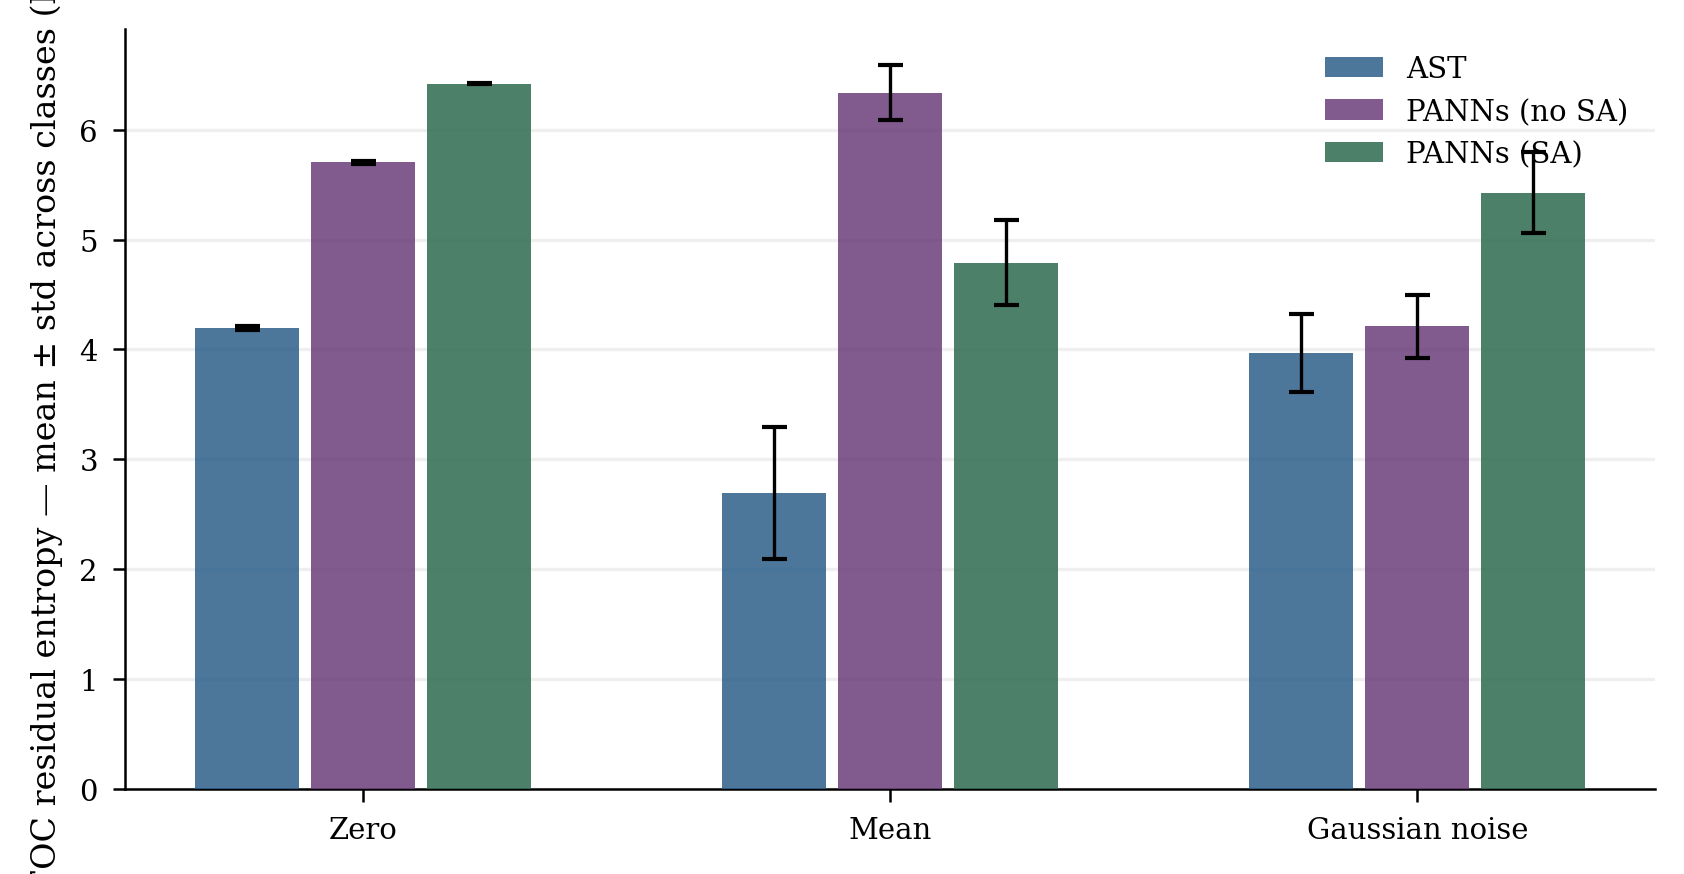

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 2.8))

x       = np.arange(len(FILLS))
width   = 0.22
offsets = [-width, 0, width]

for i, model in enumerate(MODELS):
    means, errs = [], []
    for fill in FILLS:
        vals = df_common[(df_common["model"] == model) & (df_common["fill"] == fill)]["foc_res_entropy"]
        means.append(float(vals.mean()))
        errs.append(float(vals.std()))
    ax.bar(x + offsets[i], means, width=width * 0.9,
           color=MODEL_COLORS[model], alpha=0.85,
           label=MODEL_LABELS[model], zorder=3)
    ax.errorbar(x + offsets[i], means, yerr=errs,
                fmt="none", color="black", capsize=3,
                linewidth=0.8, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels([FILL_LABELS[f] for f in FILLS])
ax.set_ylabel("FOC residual entropy — mean ± std across classes (bits)")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.2, zorder=1)
ax.legend()
plt.savefig("foc_entropy_by_model_fill.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Figure 2 — Per-Class Entropy Variation under Mean Fill

Each dot is one class. Classes are sorted left-to-right by AST mean-fill entropy (ascending). Three marker shapes, one per model.

**What to look for:**
- **AST** (circles): spread from ~2 bits (frying food — mean spectrum dominated by mains hum) to ~4 bits (harmonica). Class-specific: the mean spectrogram of each class has a distinct character that AST responds to differently.
- **PANNs (no SA)** (squares): tight cluster at 6–7 bits for every class. No class-specific structure — the model has no coherent response to the AudioSet mean spectrum at all.
- **PANNs (SA)** (triangles): intermediate spread (~4–5.5 bits), sitting between the two.

The vertical spread within AST quantifies how much class-specific information is present in the average spectrum of each class.

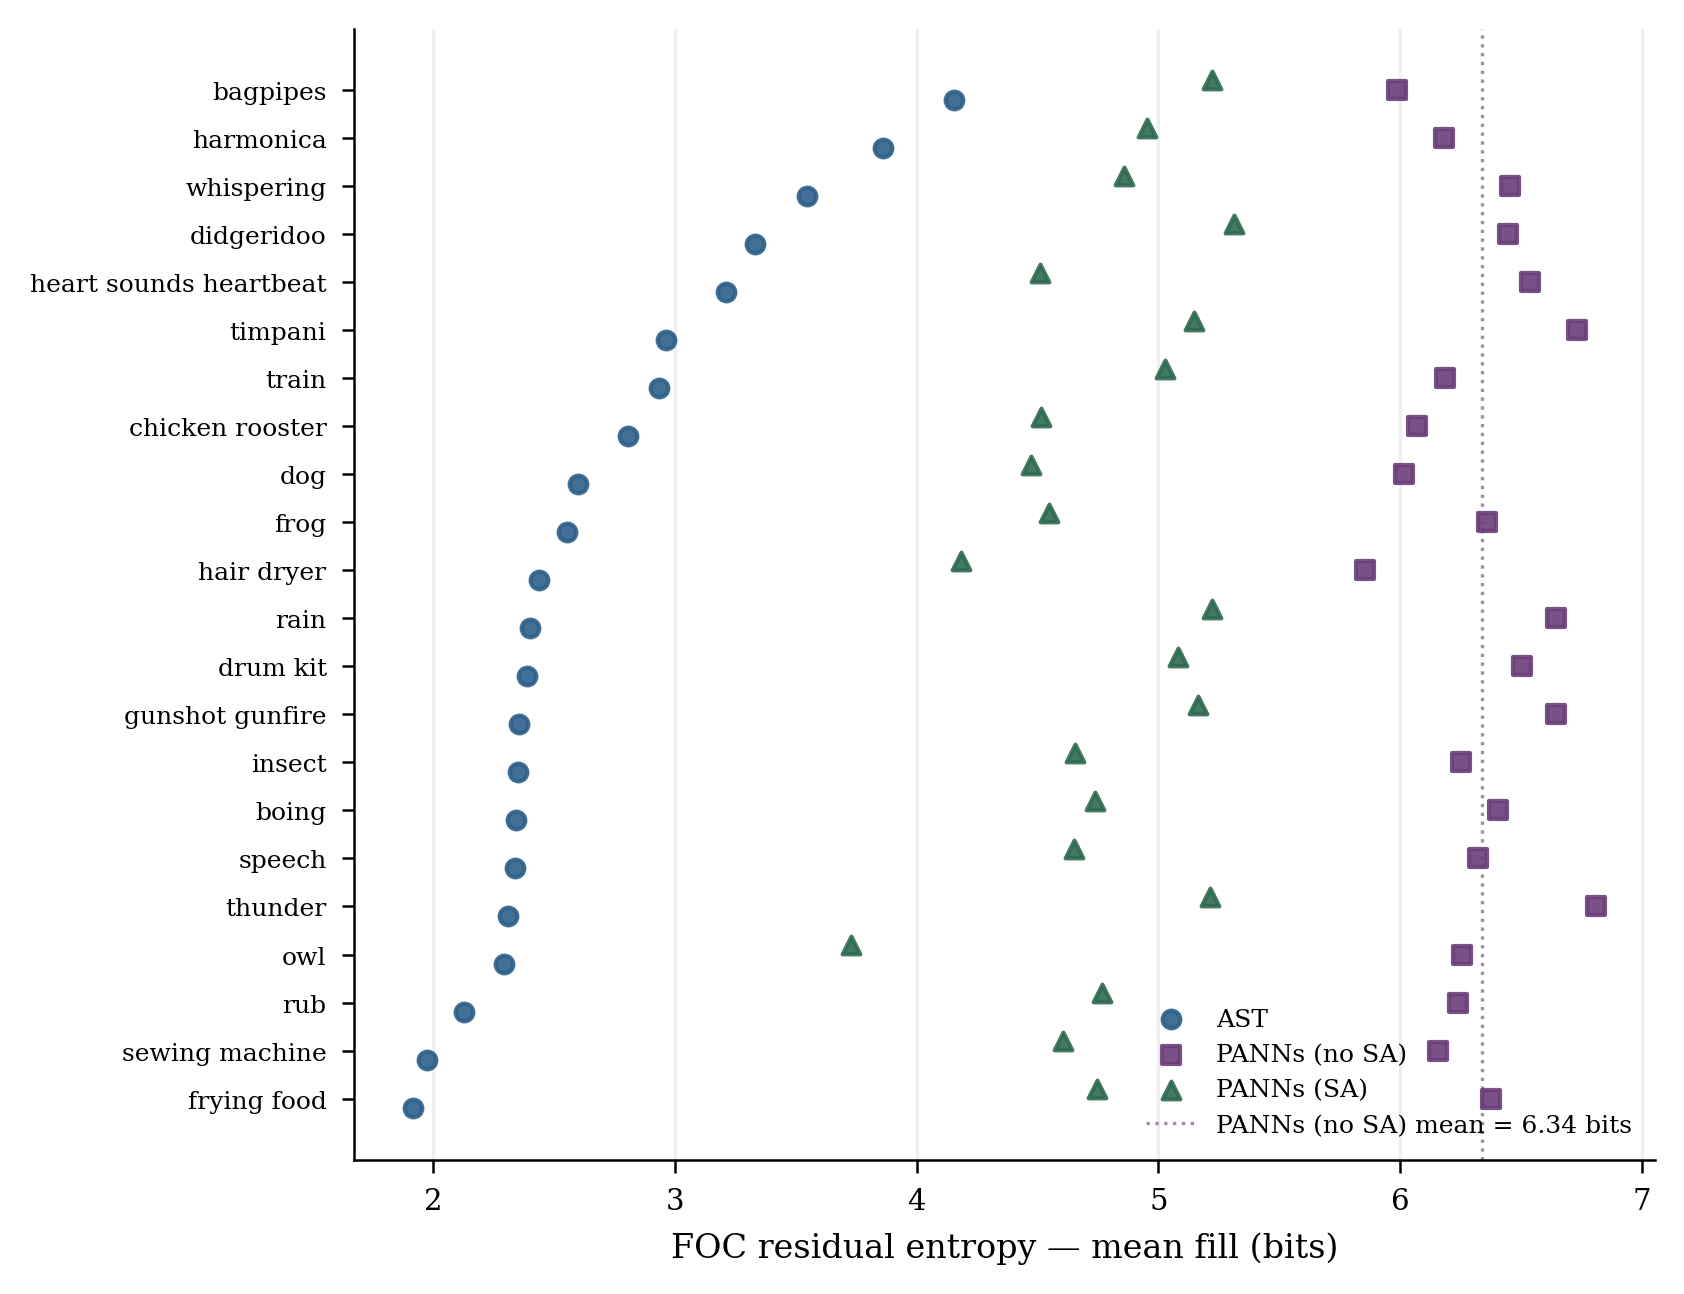

In [11]:
ast_mf = (
    df_common[(df_common["model"] == "ast_wrapper") & (df_common["fill"] == "mean")]
    .set_index("class")["foc_res_entropy"]
    .sort_values()
)
sorted_classes = ast_mf.index.tolist()
y_pos = np.arange(len(sorted_classes))
jitter = {"ast_wrapper": -0.2, "panns_no_specaug": 0.0, "panns_specaug_trained": 0.2}

fig, ax = plt.subplots(figsize=(5.5, 4.2))

for model in MODELS:
    subset = (
        df_common[(df_common["model"] == model) & (df_common["fill"] == "mean")]
        .set_index("class")
    )
    x_vals = [
        float(subset.loc[c, "foc_res_entropy"]) if c in subset.index else np.nan
        for c in sorted_classes
    ]
    y_vals = y_pos + jitter[model]
    ax.scatter(x_vals, y_vals,
               color=MODEL_COLORS[model], marker=MODEL_MARKERS[model],
               s=18, alpha=0.9, label=MODEL_LABELS[model], zorder=3)

panns_nosa_mean = float(
    df_common[(df_common["model"] == "panns_no_specaug") & (df_common["fill"] == "mean")]["foc_res_entropy"].mean()
)
ax.axvline(panns_nosa_mean, ls=":", lw=0.8, color=MODEL_COLORS["panns_no_specaug"],
           alpha=0.6, label=f"PANNs (no SA) mean = {panns_nosa_mean:.2f} bits")

ax.set_yticks(y_pos)
ax.set_yticklabels([c.replace("_", " ") for c in sorted_classes], fontsize=6)
ax.set_xlabel("FOC residual entropy — mean fill (bits)")
ax.grid(axis="x", alpha=0.2, zorder=1)
ax.legend(loc="lower right", fontsize=6)
plt.savefig("foc_entropy_strip_mean_fill.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Figure 3 — Entropy Concentration: Total vs Top-5 Contribution

x-axis: total FOC residual entropy (how spread is the fill's output distribution?). y-axis: fraction of that entropy explained by just the top-5 non-target classes.

**Four interpretable regions:**
- **Bottom-left** (low entropy, low top-5 fraction): fill activates one or two dominant classes but many small contributors spread the entropy — unusual.
- **Bottom-right** (high entropy, low top-5 fraction): fill is generic — high total spread, and the top-5 barely explain any of it. The mass is diffuse across hundreds of classes.
- **Top-left** (low entropy, high top-5 fraction): fill is class-distinctive — a small number of classes dominate and account for nearly all the entropy. Ideal condition for controlled perturbation.
- **Top-right** (high entropy, high top-5 fraction): fill is moderately distinctive but still high entropy — the top-5 explain most of the spread but the spread itself is large.

PANNs (SA) zero fill sits bottom-right: very high entropy, top-5 explains only ~18%. PANNs (no SA) mean fill similarly. AST mean fill tends top-left: low entropy, top-5 explains ~90%+.

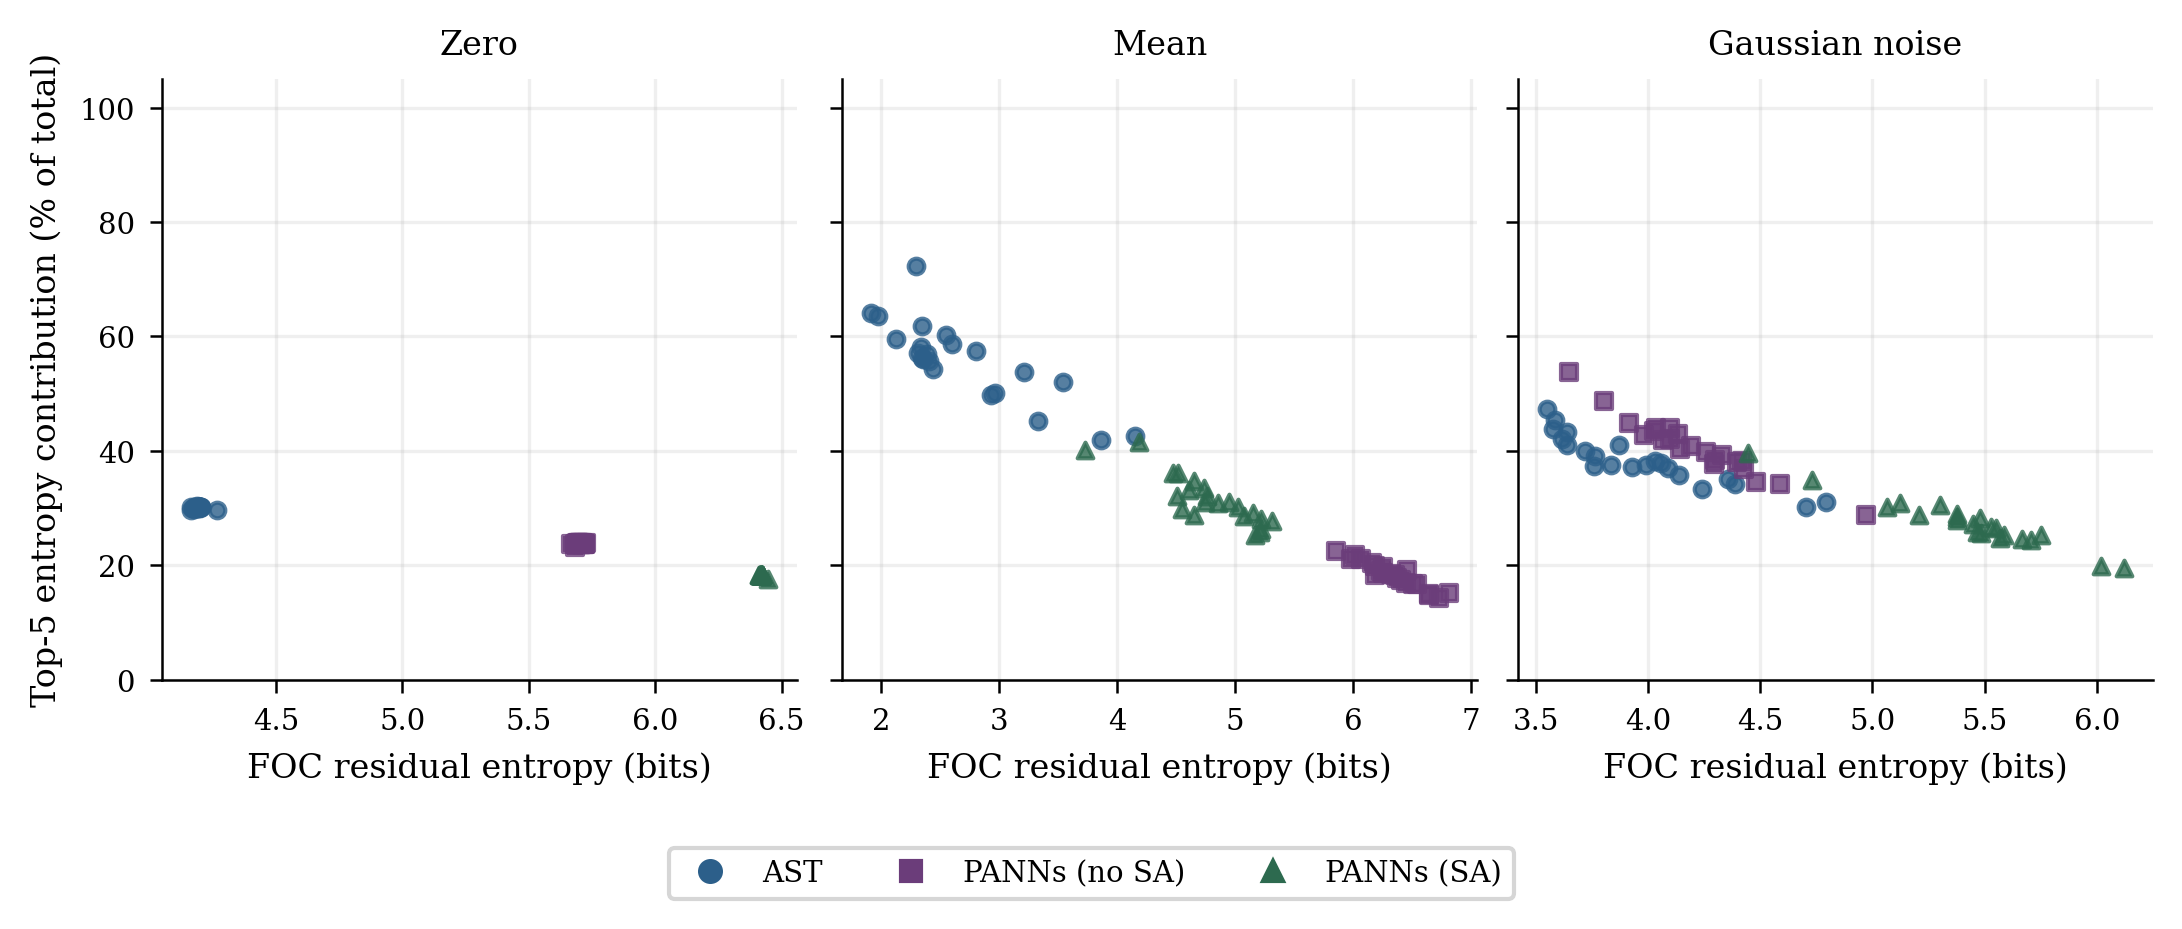

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(7.16, 2.6), sharey=True, sharex=False)

for ax, fill in zip(axes, FILLS):
    for model in MODELS:
        sub = df_common[(df_common["model"] == model) & (df_common["fill"] == fill)].copy()
        sub["top5_pct"] = sub["top5_entropy_contrib"] / sub["foc_res_entropy"] * 100
        ax.scatter(
            sub["foc_res_entropy"], sub["top5_pct"],
            color=MODEL_COLORS[model], marker=MODEL_MARKERS[model],
            s=14, alpha=0.8, label=MODEL_LABELS[model], zorder=3,
        )
    ax.set_title(FILL_LABELS[fill])
    ax.set_xlabel("FOC residual entropy (bits)")
    ax.grid(alpha=0.2, zorder=1)
    ax.set_ylim(0, 105)

axes[0].set_ylabel("Top-5 entropy contribution (% of total)")

handles = [
    Line2D([0], [0], marker=MODEL_MARKERS[m], color=MODEL_COLORS[m],
           markersize=5, linestyle="none", label=MODEL_LABELS[m])
    for m in MODELS
]
fig.legend(handles=handles, loc="lower center",
           bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=7,
           frameon=True)
plt.savefig("foc_entropy_concentration.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Figure 4 — Top-1 vs Cumulative Top-5 Confidence at Full Occlusion

For each class × model × fill: dark bar = sigmoid confidence of the top-1 non-target class; faded bar = sum of sigmoid confidences across the top-5 non-target classes. Classes sorted as in Figure 2 (AST mean-fill entropy, ascending).

**What to look for:** The gap between top-1 and top-5 (sum) shows how steeply the ranked distribution drops off. A narrow gap means one class dominates (concentrated). A wide gap means confidence is spread across positions 2–5 (distributed). AST zero fill: top-1 (Silence) at ~0.61, top-5 sum ~0.75 — very concentrated. PANNs (SA) zero fill: top-1 (Music) at ~0.19, top-5 sum ~0.34 — flatter, more diffuse.

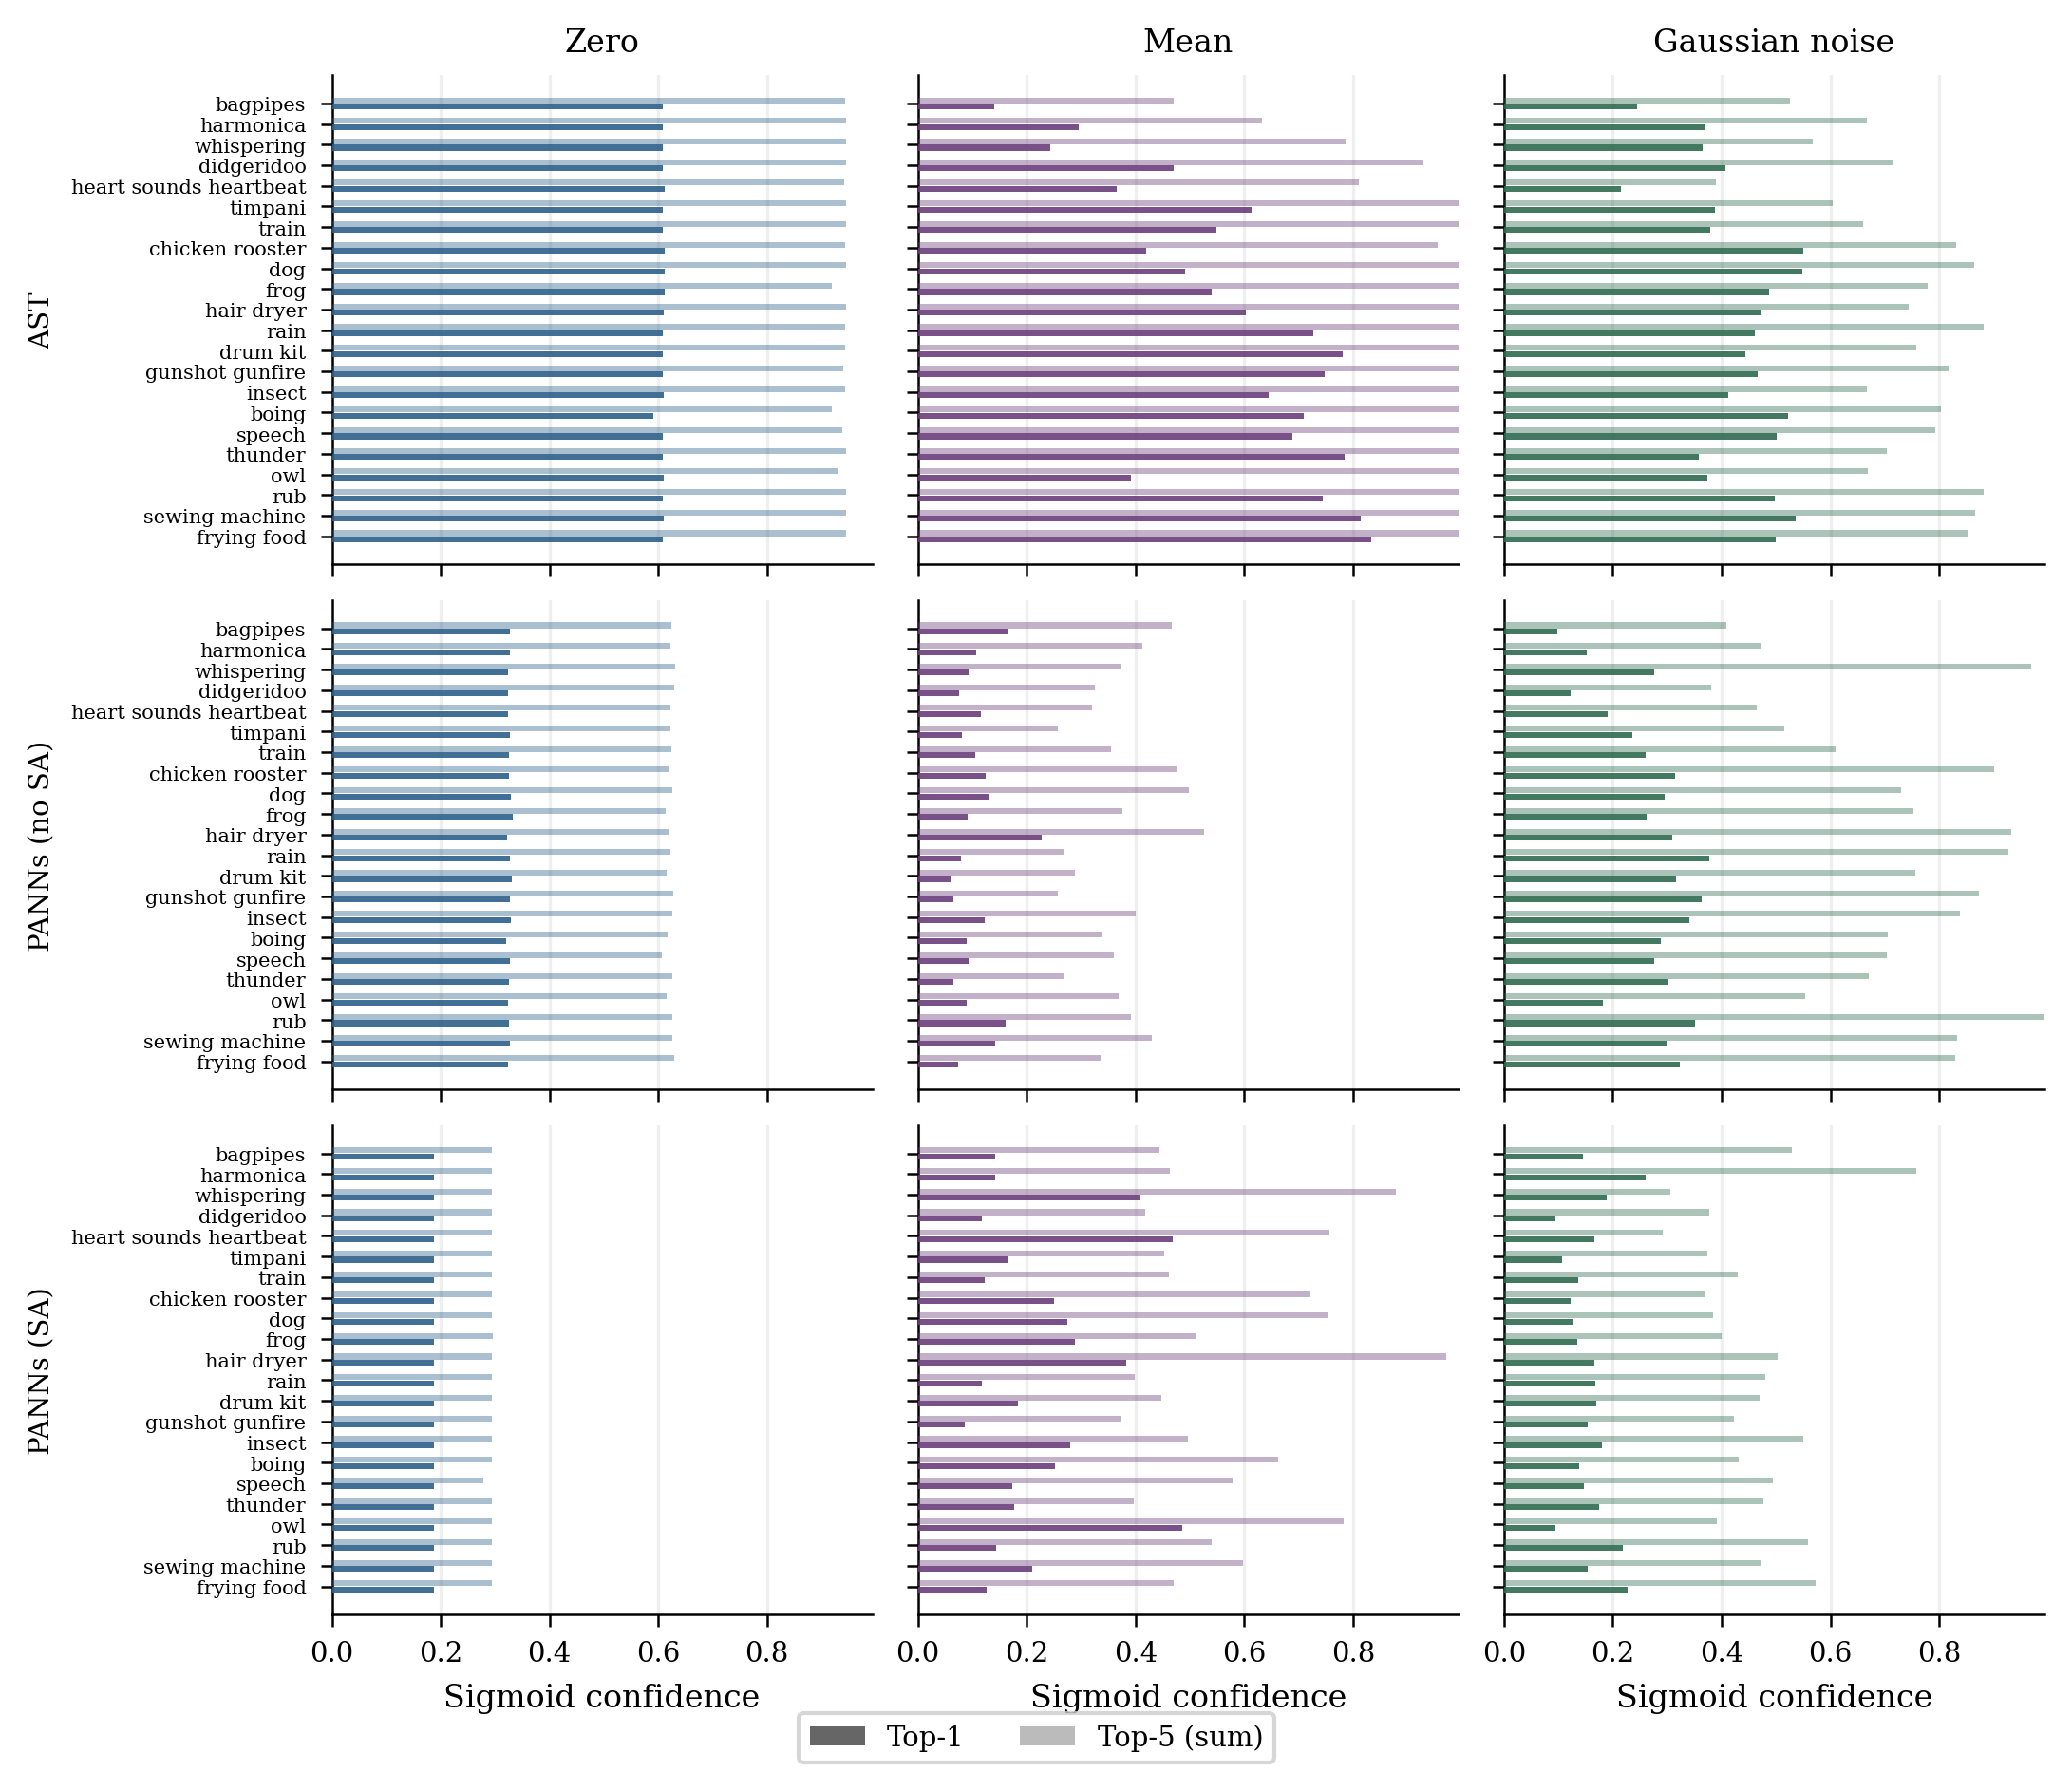

In [13]:
if "sorted_classes" not in dir():
    _ast_mf = (df_common[(df_common["model"] == "ast_wrapper") & (df_common["fill"] == "mean")]
               .set_index("class")["foc_res_entropy"]
               .sort_values())
    sorted_classes = _ast_mf.index.tolist()
    y_pos = np.arange(len(sorted_classes))

fig, axes = plt.subplots(3, 3, figsize=(7.16, 6.0), sharey="row", sharex=True)

for row_i, model in enumerate(MODELS):
    for col_i, fill in enumerate(FILLS):
        ax = axes[row_i, col_i]
        subset = (
            df_common[(df_common["model"] == model) & (df_common["fill"] == fill)]
            .set_index("class")
        )
        top1 = [float(subset.loc[c, "top1_conf"]) if c in subset.index else np.nan
                for c in sorted_classes]
        top5_cumsum = [
            sum(float(subset.loc[c, f"top{k}_conf"]) for k in range(1, 6))
            if c in subset.index else np.nan
            for c in sorted_classes
        ]

        ax.barh(y_pos - 0.15, top1,        height=0.28,
                color=COLORS[fill], alpha=0.9, label="Top-1", zorder=3)
        ax.barh(y_pos + 0.15, top5_cumsum, height=0.28,
                color=COLORS[fill], alpha=0.4, label="Top-5 (sum)", zorder=3)

        if row_i == 0:
            ax.set_title(FILL_LABELS[fill])
        if col_i == 0:
            ax.set_ylabel(MODEL_LABELS[model], fontsize=7)
            ax.set_yticks(y_pos)
            ax.set_yticklabels([c.replace("_", " ") for c in sorted_classes], fontsize=5)
        if row_i == 2:
            ax.set_xlabel("Sigmoid confidence")
        ax.set_xlim(0, None)
        ax.grid(axis="x", alpha=0.2, zorder=1)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#555555", alpha=0.9, label="Top-1"),
    Patch(facecolor="#555555", alpha=0.4, label="Top-5 (sum)"),
]
fig.legend(handles=legend_handles, loc="lower center",
           bbox_to_anchor=(0.5, -0.03), ncol=2, fontsize=7, frameon=True)
plt.savefig("foc_top1_top5_confidence.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Numeric Summary

In [14]:
print("Mean FOC residual entropy (bits) by model × fill (22 common classes)")
pivot = (
    df_common.groupby(["model", "fill"])["foc_res_entropy"]
    .mean()
    .unstack("fill")
    [["zero", "mean", "gaussian_noise"]]
    .rename(columns=FILL_LABELS)
    .rename(index=MODEL_LABELS)
)
print(pivot.round(3).to_string())

print("\nMean top-5 entropy contribution (%) by model × fill (22 common classes)")
df_common_copy = df_common.copy()
df_common_copy["top5_pct"] = df_common_copy["top5_entropy_contrib"] / df_common_copy["foc_res_entropy"] * 100
pivot2 = (
    df_common_copy.groupby(["model", "fill"])["top5_pct"]
    .mean()
    .unstack("fill")
    [["zero", "mean", "gaussian_noise"]]
    .rename(columns=FILL_LABELS)
    .rename(index=MODEL_LABELS)
)
print(pivot2.round(1).to_string())

Mean FOC residual entropy (bits) by model × fill (22 common classes)
fill            Zero   Mean  Gaussian noise
model                                      
AST            4.193  2.692           3.967
PANNs (no SA)  5.703  6.338           4.209
PANNs (SA)     6.420  4.787           5.426

Mean top-5 entropy contribution (%) by model × fill (22 common classes)
fill           Zero  Mean  Gaussian noise
model                                    
AST            30.1  55.8            38.4
PANNs (no SA)  23.8  18.3            40.7
PANNs (SA)     18.3  31.5            27.5


Row sums vs expected n=22:
  AST                  Mean             sum=22  OK
  AST                  Gaussian noise   sum=22  OK
  PANNs (no SA)        Mean             sum=22  OK
  PANNs (no SA)        Gaussian noise   sum=22  OK
  PANNs (SA)           Mean             sum=22  OK
  PANNs (SA)           Gaussian noise   sum=22  OK


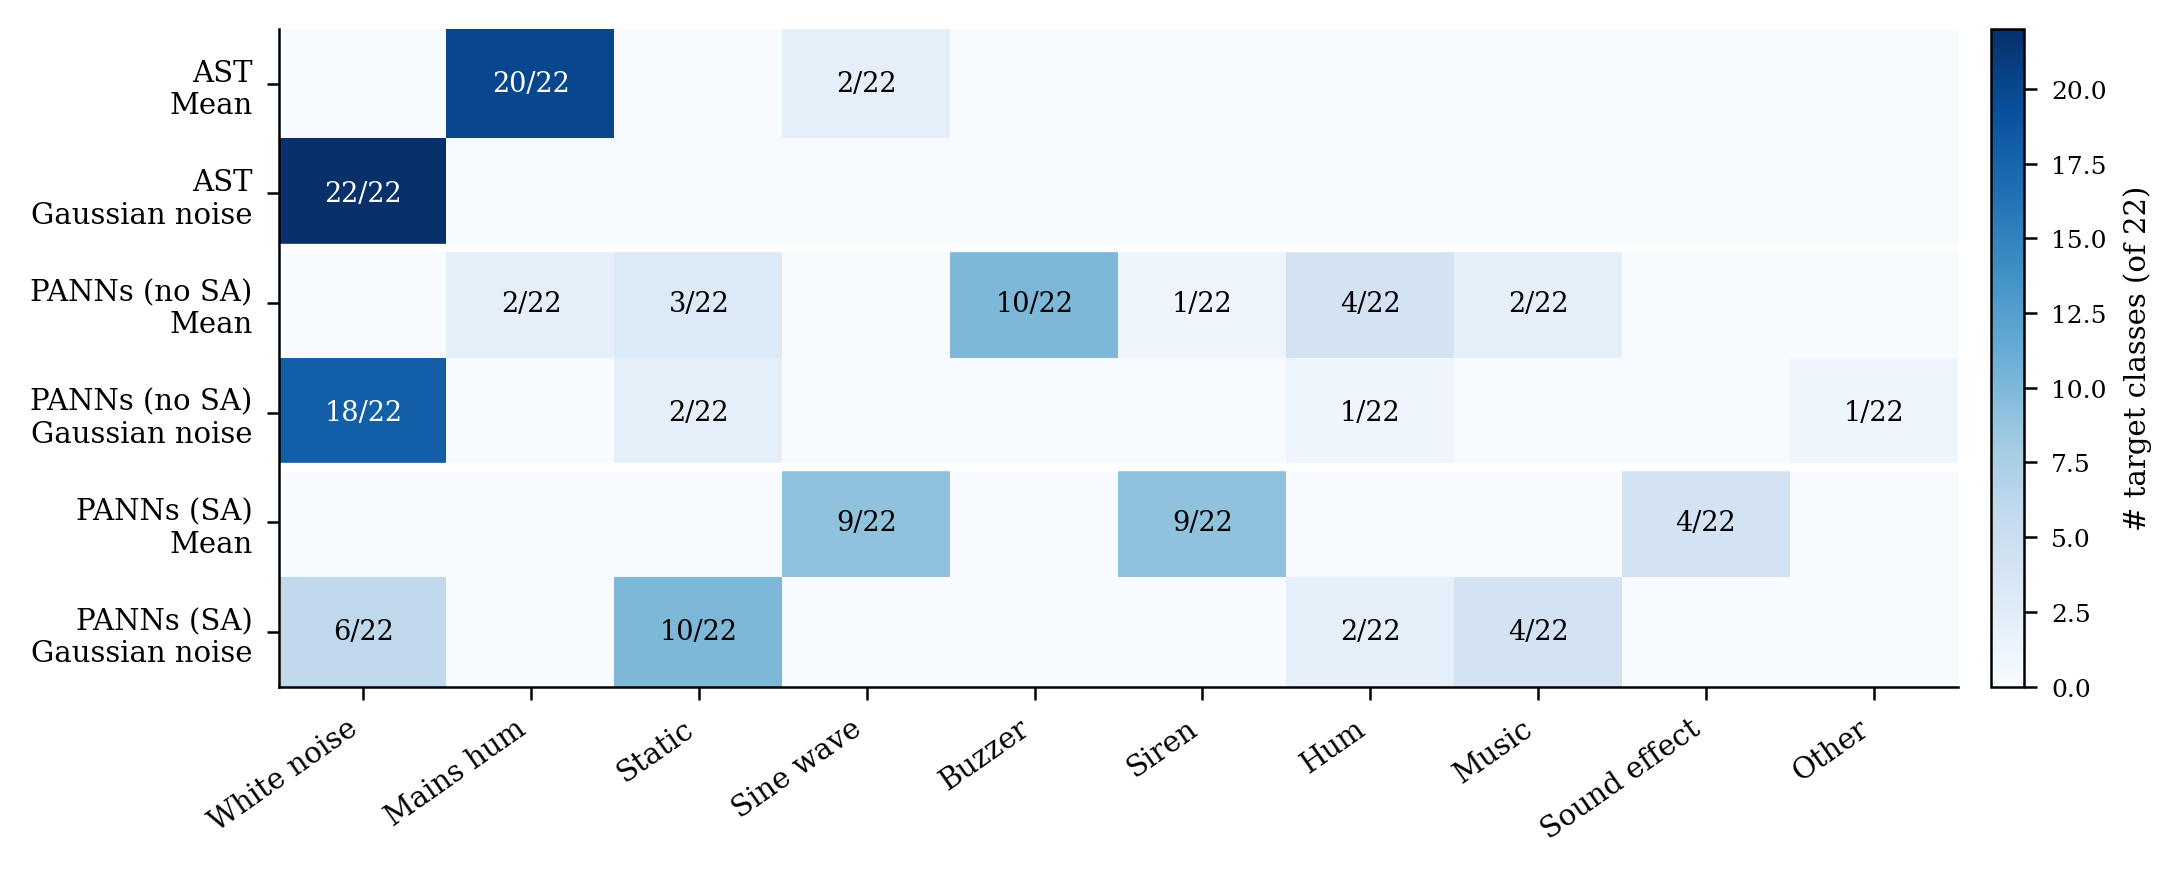

In [15]:
# ── FOC top-1 class heatmap: mean & Gaussian fills ───────────────────────────
# Uses df_common (22 classes common to all models, defined in cell 9afe44b6).

FILLS_PLOT = ["mean", "gaussian_noise"]
N          = len(common_classes)  # 22

conditions  = [(m, f) for m in MODELS for f in FILLS_PLOT]
cond_labels = [f"{MODEL_LABELS[m]}\n{FILL_LABELS[f]}" for m, f in conditions]

# Top-1 class frequency per condition
freq = {}
for model, fill in conditions:
    subset = df_common[(df_common["model"] == model) & (df_common["fill"] == fill)]
    freq[(model, fill)] = (
        subset["top1_idx"].astype(int).map(idx_to_name).value_counts()
    )

# Keep classes that are top-1 for >= 2 target classes in at least one condition
all_classes = set(c for counts in freq.values() for c in counts.index)
keep = sorted(
    [c for c in all_classes if any(freq[k].get(c, 0) >= 2 for k in freq)],
    key=lambda c: -sum(freq[k].get(c, 0) for k in freq),
)

# Build count matrix; last column = Other
matrix = np.zeros((len(conditions), len(keep) + 1))
for i, cond in enumerate(conditions):
    counts = freq[cond]
    for j, cls in enumerate(keep):
        matrix[i, j] = counts.get(cls, 0)
    matrix[i, -1] = N - matrix[i, :-1].sum()

col_labels = keep + ["Other"]
if matrix[:, -1].sum() == 0:
    matrix, col_labels = matrix[:, :-1], keep

# Sanity check
print("Row sums vs expected n=22:")
for i, cond in enumerate(conditions):
    s = int(matrix[i].sum())
    print(f"  {MODEL_LABELS[cond[0]]:20s} {FILL_LABELS[cond[1]]:15s}"
          f"  sum={s}  {'OK' if s == N else 'MISMATCH'}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.16, 2.8))

im = ax.imshow(matrix, aspect="auto", cmap="Blues", vmin=0, vmax=N)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = int(matrix[i, j])
        if val > 0:
            color = "white" if val > N * 0.55 else "black"
            ax.text(j, i, f"{val}/{N}", ha="center", va="center",
                    fontsize=6.5, color=color)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=35, ha="right", fontsize=7)
ax.set_yticks(range(len(cond_labels)))
ax.set_yticklabels(cond_labels, fontsize=7)

for sep in [2, 4]:
    ax.axhline(sep - 0.5, color="white", linewidth=2)

cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("# target classes (of 22)", fontsize=7)
cb.ax.tick_params(labelsize=6)

plt.savefig("foc_top1_heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [13]:
# ── Save heatmap data to CSV ──────────────────────────────────────────────────
# Counts of target classes (of 22 common classes) producing each top-1 activation.

out = pd.DataFrame(matrix.astype(int), columns=col_labels)
out.insert(0, "n_classes", N)
out.insert(0, "fill",  [FILL_LABELS[f] for _, f in conditions])
out.insert(0, "model", [MODEL_LABELS[m] for m, _ in conditions])

out.to_csv("foc_top1_heatmap.csv", index=False)
print(out.to_string(index=False))

        model           fill  n_classes  White noise  Mains hum  Static  Sine wave  Siren  Buzzer  Hum  Music  Sound effect  Other
          AST           Mean         22            0         20       0          2      0       0    0      0             0      0
          AST Gaussian noise         22           22          0       0          0      0       0    0      0             0      0
PANNs (no SA)           Mean         22            0          2       3          0      1      10    4      2             0      0
PANNs (no SA) Gaussian noise         22           18          0       2          0      0       0    1      0             0      1
   PANNs (SA)           Mean         22            0          0       0          9      9       0    0      0             4      0
   PANNs (SA) Gaussian noise         22            6          0      10          0      0       0    2      4             0      0


In [ ]:
# ── Gaussian noise FOC summary (paper stats) ─────────────────────────────────
# Mirrors Table 1 structure for zero fill: modal top-1 class, agreement,
# mean top-1 confidence, and mean entropy per model.

gn = df_common[df_common["fill"] == "gaussian_noise"].copy()
gn["top1_name"] = gn["top1_idx"].astype(int).map(idx_to_name)

hdr = "{:16s}  {:18s}  {:>12s}  {:>10s}  {:>14s}".format(
    "Model", "Modal top-1", "Agreement", "Top-1 conf", "Entropy (bits)"
)
print("Gaussian Noise FOC Summary (22 common classes)")
print("=" * len(hdr))
print(hdr)
print("─" * len(hdr))
for model in MODELS:
    sub = gn[gn["model"] == model]
    modal_class = sub["top1_name"].mode()[0]
    agreement   = int((sub["top1_name"] == modal_class).sum())
    mean_conf   = float(sub[sub["top1_name"] == modal_class]["top1_conf"].mean())
    mean_h      = float(sub["foc_res_entropy"].mean())
    print("{:16s}  {:18s}  {:>8d}/22  {:>10.3f}  {:>14.3f}".format(
        MODEL_LABELS[model], modal_class, agreement, mean_conf, mean_h
    ))

In [ ]:
# ── Mean fill FOC summary (paper stats) ──────────────────────────────────────
# Mirrors GN summary: modal top-1 class, agreement, mean top-1 confidence,
# and mean entropy per model.

mf = df_common[df_common["fill"] == "mean"].copy()
mf["top1_name"] = mf["top1_idx"].astype(int).map(idx_to_name)

hdr = "{:16s}  {:18s}  {:>12s}  {:>10s}  {:>14s}".format(
    "Model", "Modal top-1", "Agreement", "Top-1 conf", "Entropy (bits)"
)
print("Mean Fill FOC Summary (22 common classes)")
print("=" * len(hdr))
print(hdr)
print("─" * len(hdr))
for model in MODELS:
    sub = mf[mf["model"] == model]
    modal_class = sub["top1_name"].mode()[0]
    agreement   = int((sub["top1_name"] == modal_class).sum())
    mean_conf   = float(sub[sub["top1_name"] == modal_class]["top1_conf"].mean())
    mean_h      = float(sub["foc_res_entropy"].mean())
    print("{:16s}  {:18s}  {:>8d}/22  {:>10.3f}  {:>14.3f}".format(
        MODEL_LABELS[model], modal_class, agreement, mean_conf, mean_h
    ))

print("\nTop-3 modal classes per model (mean fill):")
for model in MODELS:
    sub = mf[mf["model"] == model]
    top3 = sub["top1_name"].value_counts().head(3)
    print(f"\n  {MODEL_LABELS[model]}")
    for cls, cnt in top3.items():
        mean_conf = float(sub[sub["top1_name"] == cls]["top1_conf"].mean())
        print(f"    {cls:25s}  {cnt}/22  conf={mean_conf:.3f}")